<a href="https://colab.research.google.com/github/HanTanto/credit-card-fraud-detection/blob/main/ANN_Fraud_Detection.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>


1. **Sigmoid** :  $a(t)=\frac{1}{1+e^{-t}}$

2. **ReLu**  :  $f(t) = max(0,t)$
3. **Soft max** : $f(z_i) = \frac{e^{z_i}}{\sum_{j=1}^{K}e^{z_j}}$ (Cocok untuk multi kelas)
4. **Swiss** :  $a(t)=\frac{t}{1+e^{-t}}$

**Back propagation**

$\Delta_W (t) = -\epsilon \frac{dE}{dW_t}+\alpha\Delta_W(t-1)$
1. $\Delta_w(t)$: Gradien pada waktu t
2. $0<\epsilon<=0$: Bias
3. $W_t$: matriks bobot
4. $\alpha$: learning rate

**Parameter pada `compile`**
```
from tensorflow.keras.optimizers import Adam
model.compile(optimizer=Adam(learning_rate=0.001), loss='categorical_crossentropy', metrics=['accuracy'])
```
1. `optimizer`: Parameter ini menentukan algoritma optimisasi yang digunakan untuk memperbarui bobot model berdasarkan gradien yang dihitung.
- `"adam"`: Optimizer adaptif yang sangat populer, menggabungkan keuntungan dari optimizers RMSProp dan momentum. Cocok untuk kebanyakan kasus.
- `"sgd"`: Stochastic Gradient Descent. Optimizer dasar yang sering digunakan.
- `"rmsprop"`: Optimizer adaptif yang lebih cocok untuk masalah deret waktu atau data sekuensial.
- `"adagrad"`, "adadelta", "nadam": Variasi optimizers lain yang bisa digunakan tergantung kebutuhan.

2. `loss`: Loss function digunakan untuk menghitung seberapa jauh prediksi model dari nilai aktual.
- Klasifikasi
  - `"categorical_crossentropy"`: Untuk masalah klasifikasi multi-kelas (kategori lebih dari dua) dan output berupa one-hot encoding.
  - `"sparse_categorical_crossentropy"`: Untuk masalah klasifikasi multi-kelas dengan output berupa integer labels.
  - `"binary_crossentropy"`: Untuk masalah klasifikasi biner (dua kelas).
- Regresi
  - `"mean_squared_error"`: Untuk masalah regresi dengan target numerik.
  - `"mean_absolute_error"`: Untuk regresi, menghitung rata-rata perbedaan absolut antara prediksi dan nilai sebenarnya.

3. `metric`: Metrik digunakan untuk mengevaluasi kinerja model selama pelatihan dan evaluasi. Metrik ini tidak memengaruhi proses optimasi (seperti loss), tetapi hanya memberikan informasi tentang performa model.
- `"accuracy"`: Metrik yang umum untuk klasifikasi, menghitung persentase prediksi yang benar.
- `"mae"` (Mean Absolute Error): Digunakan dalam regresi untuk menghitung rata-rata kesalahan absolut antara prediksi dan nilai sebenarnya.
- `"mse"` (Mean Squared Error): Juga digunakan dalam regresi, menghitung rata-rata kesalahan kuadrat antara prediksi dan nilai sebenarnya.
- `"AUC"`: Area Under the Curve, sering digunakan dalam masalah klasifikasi biner.
- `"precision"`, `"recall"`, `"f1-score"`: Metrik yang digunakan dalam evaluasi klasifikasi.

**Parameter pada `fit()`**
1. `batch_size`: Menentukan jumlah sampel yang diproses sebelum model memperbarui bobotnya. Batch size memengaruhi penggunaan memori dan stabilitas pelatihan.

- `batch_size` kecil: Lebih sering memperbarui bobot, tetapi pelatihan bisa lebih lambat dan rentan terhadap fluktuasi.
- `batch_size` besar: Memperbarui bobot lebih jarang, tetapi memerlukan lebih banyak memori dan bisa lebih stabil.

# **Import Dataset**

Dataset yang digunakan yaitu data transaksi kartu kredit selama 2 tahun yaitu pada 1 Januari 2019 s.d 31 desember 2020.

In [ ]:
# @title Default title text
import zipfile
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder,StandardScaler
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score,confusion_matrix,f1_score,recall_score,precision_score

```
import kagglehub
import os
import pandas as pd

# Assuming you have a DataFrame named 'df' that you want to download as a CSV
# Replace 'df' with the actual name of your DataFrame if it's different
dataset_path = kagglehub.dataset_download("kartik2112/fraud-detection")

# Find all CSV files
for filename in os.listdir(dataset_path):
  if filename.endswith(".csv"):
    filepath = os.path.join(dataset_path, filename)
    df = pd.read_csv(filepath)
    # Download the DataFrame as a CSV to your Colab Files
    df.to_csv(filename, index=False)
    print(f"{filename} downloaded to Colab Files.")
```

In [ ]:
# @title Default title text
from google.colab import drive
drive.mount('/content/gdrive')

Mounted at /content/gdrive


In [ ]:
%cd /content/gdrive/MyDrive/Magister/Semester 1/Machine Learning dan AI

/content/gdrive/MyDrive/Magister/Semester 1/Machine Learning dan AI


In [ ]:
# @title Default title text
file_csv1 = 'fraudTrain.csv.zip'
file_csv2 = 'fraudTest.csv.zip'

with zipfile.ZipFile(file_csv1, 'r') as zip_ref:
    csv_filename = zip_ref.namelist()[0]
    with zip_ref.open(csv_filename) as csv_file:
        data1 = pd.read_csv(csv_file)
with zipfile.ZipFile(file_csv2, 'r') as zip_ref:
    csv_filename = zip_ref.namelist()[0]
    with zip_ref.open(csv_filename) as csv_file:
        data2 = pd.read_csv(csv_file)
data = pd.concat([data1,data2]).reset_index()

**data For validation**

Pilih 10 datum yang normal dan 10 datum yang positif berupa penipuan.

In [ ]:
data_0 = data[data['is_fraud']==0].dropna(axis=0)
data_1 = data[data['is_fraud']==1].dropna(axis=0)
data_valid_0 = data_0.sample(10, random_state=1)
data_valid_1 = data_1.sample(10, random_state=2)
data_validation = pd.concat([data_valid_0, data_valid_1]).reset_index()

data=pd.concat([data_0.drop(index=data_valid_0.index),data_1.drop(index=data_valid_1.index)]).sample(frac=True).reset_index()

In [ ]:
data_validation.head()

,level_0,index,Unnamed: 0,trans_date_trans_time,cc_num,merchant,category,amt,first,last,...,lat,long,city_pop,job,dob,trans_num,unix_time,merch_lat,merch_long,is_fraud
0,140582,140582,140582,2019-03-17 17:21:27,4642255475285942,fraud_Gleason and Sons,kids_pets,67.46,Sabrina,Johnson,...,38.9999,-109.6150,46,"Surveyor, minerals",1987-04-23,f457666b629198de3359cde0c1da7326,1332004887,39.064692,-109.202439,0
1,933858,933858,933858,2020-01-06 06:16:46,341546199006537,fraud_Durgan-Auer,misc_net,5.44,Mark,Brown,...,64.7556,-165.6723,145,"Administrator, education",1939-11-09,2601b767b799a60050b0096298a58fd2,1357453006,63.790433,-165.758429,0
2,1075399,1075399,1075399,2020-03-22 23:03:49,4502539526809429801,fraud_Renner Ltd,home,72.21,Stephanie,Cummings,...,36.2201,-91.6421,2856,Hydrologist,1926-08-27,e091207784cdb1315d0f97e31fce2edd,1363993429,36.641771,-91.948231,0
3,701698,701698,701698,2019-10-26 21:52:16,6011724471098086,fraud_Waters-Cruickshank,health_fitness,23.99,Ann,Lawson,...,46.1966,-118.9017,3684,Musician,1981-11-29,b871d0e4045201757691db24da1522fa,1351288336,45.256328,-118.823581,0
4,1186404,1186404,1186404,2020-05-10 22:07:51,30551643947183,"fraud_Hermiston, Russel and Price",food_dining,71.83,Morgan,Smith,...,35.1836,-81.4552,5621,Toxicologist,1973-11-14,da9304a6f3369ca65c4cc47a76b1ac26,1368223671,34.280288,-81.593235,0


# **Data Preprosessing**

## **Initial EDA**

In [ ]:
data.head(3)

,level_0,index,Unnamed: 0,cc_num,merchant,amt,first,last,gender,street,...,misc_pos,personal_care,shopping_net,shopping_pos,travel,trans_day,trans_month,trans_year,trans_hour,trans_minute
0,396515,396515,396515,0.006367,fraud_Kunze Inc,194.03,Jennifer,Bishop,F,589 Matthew Brooks,...,0,0,0,0,0,30,6,2019,4,10
1,777124,777124,777124,0.005005,"fraud_Osinski, Ledner and Leuschke",110.93,Jason,Mcmahon,M,6385 Donald Square Suite 429,...,0,0,0,0,0,29,11,2019,8,45
2,1013121,1013121,1013121,0.004105,fraud_Corwin-Collins,43.70,Teresa,Stein,F,2838 White Fields Apt. 473,...,0,0,0,0,0,22,2,2020,4,31


In [ ]:
data.sample(3)

,level_0,index,Unnamed: 0,cc_num,merchant,amt,first,last,gender,street,...,misc_pos,personal_care,shopping_net,shopping_pos,travel,trans_day,trans_month,trans_year,trans_hour,trans_minute
859274,27540,27540,27540,0.003763,fraud_Marvin-Lind,77.53,Omar,Gay,M,2161 Blankenship Freeway,...,0,1,0,0,0,16,1,2019,21,23
639772,1814840,518165,518165,0.004438,fraud_Kuhic LLC,5.89,Theresa,Blackwell,F,43576 Kristina Islands,...,0,0,1,0,0,23,12,2020,3,30
1601928,191577,191577,191577,0.004100,fraud_Hoppe-Parisian,249.14,Alicia,Bishop,F,222 Freeman Islands,...,0,0,0,0,0,8,4,2019,19,10


In [ ]:
data.tail(3)

,level_0,index,Unnamed: 0,cc_num,merchant,amt,first,last,gender,street,...,misc_pos,personal_care,shopping_net,shopping_pos,travel,trans_day,trans_month,trans_year,trans_hour,trans_minute
1852371,1006325,1006325,1006325,0.001827,fraud_Treutel-King,7.00,Kristen,Hanson,F,26544 Andrea Glen,...,0,0,0,0,1,17,2,2020,13,24
1852372,1472647,175972,175972,0.003653,fraud_Cummings Group,98.07,Wayne,Payne,M,587 Bradley Inlet Suite 281,...,0,0,0,0,0,22,8,2020,8,3
1852373,1523682,227007,227007,0.009537,fraud_Herzog Ltd,97.67,Karen,Sullivan,F,6313 Scott Trace,...,1,0,0,0,0,10,9,2020,14,33


In [ ]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1852374 entries, 0 to 1852373
Data columns (total 42 columns):
 #   Column          Dtype  
---  ------          -----  
 0   level_0         int64  
 1   index           int64  
 2   Unnamed: 0      int64  
 3   cc_num          float64
 4   merchant        object 
 5   amt             float64
 6   first           object 
 7   last            object 
 8   gender          object 
 9   street          object 
 10  city            object 
 11  state           object 
 12  zip             int64  
 13  lat             float64
 14  long            float64
 15  city_pop        int64  
 16  job             object 
 17  dob             object 
 18  trans_num       object 
 19  unix_time       int64  
 20  merch_lat       float64
 21  merch_long      float64
 22  is_fraud        int64  
 23  entertainment   int64  
 24  food_dining     int64  
 25  gas_transport   int64  
 26  grocery_net     int64  
 27  grocery_pos     int64  
 28  health_fitne

## **Drop Unused Columns**

Pelaku kemungkinan memberikan informasi palsu terkait data pribadi ketika menerbitkan kartu kredit sehinga beberapa informasi terkait pemegang kartu kredit harus dieliminasi seperti nama, alamat, jenis kelamin, tanggal lahir,dan pekerjaan. Kemudian ada beberapa informasi yang tidak perlu dimasukkan seperti nomor transaksi. Selain itu informasi merchant sudah diwakili oleh lokasi merchant. Berikut beberapa feature yang akan didrop

```
['Unnamed: 0','first','last','street','gender','job','dob','city','state','trans_num','merchant']
```

In [ ]:
data.drop(columns=['level_0','index','Unnamed: 0','first','last','street','gender','unix_time','job','dob','city','state','trans_num','merchant'],inplace=True)

In [ ]:
data.head(3)

,cc_num,amt,zip,lat,long,city_pop,merch_lat,merch_long,is_fraud,entertainment,...,misc_pos,personal_care,shopping_net,shopping_pos,travel,trans_day,trans_month,trans_year,trans_hour,trans_minute
0,0.006367,194.03,7,29.7972,-95.3288,2906700,30.056677,-95.009428,0,0,...,0,0,0,0,0,30,6,2019,4,10
1,0.005005,110.93,2,38.8029,-77.2116,104396,38.628199,-77.269292,0,0,...,0,0,0,0,0,29,11,2019,8,45
2,0.004105,43.70,2,32.9413,-81.1807,1725,33.215780,-80.319983,0,0,...,0,0,0,0,0,22,2,2020,4,31


In [ ]:
for column in data.columns:
  print(f"============= {column} =================")
  display(data[column].value_counts())
  print()

============= cc_num =================


,count
cc_num,
0.000000,53289
0.004098,19764
0.004100,17560
0.003648,17544
0.006817,16137
...,...
0.010899,734
0.010914,733
0.008197,732



============= amt =================


,count
amt,
1.14,779
1.10,745
1.04,744
1.08,741
1.25,737
...,...
756.56,1
1913.40,1
873.41,1



============= zip =================


...

,count
trans_year,
2020,927537
2019,924837



============= trans_hour =================


,count
trans_hour,
23,95899
22,95367
16,94289
18,94052
21,93737
17,93513
13,93492
15,93439
19,93432



============= trans_minute =================


,count
trans_minute,
3,31302
59,31232
14,31196
40,31140
1,31096
4,31093
51,31093
42,31088
7,31079


## **Missing Value Handling**

In [ ]:
pd.isna(data).sum()

,0
cc_num,0
amt,0
zip,0
lat,0
long,0
city_pop,0
merch_lat,0
merch_long,0
is_fraud,0
entertainment,0


Tidak ada missing value pada data

## **Data Duplikat**

In [ ]:
len(data.drop_duplicates())/len(data)

1.0

Karena hasilnya satu, tidak ada data duplikatat

## **Outlier Handling & validation  and Encoding**

### **Outlier Data Numerik**

In [ ]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1852374 entries, 0 to 1852373
Data columns (total 11 columns):
 #   Column                 Dtype  
---  ------                 -----  
 0   trans_date_trans_time  object 
 1   cc_num                 int64  
 2   category               object 
 3   amt                    float64
 4   zip                    int64  
 5   lat                    float64
 6   long                   float64
 7   city_pop               int64  
 8   merch_lat              float64
 9   merch_long             float64
 10  is_fraud               int64  
dtypes: float64(5), int64(4), object(2)
memory usage: 155.5+ MB


Meskipun `cc_num` memeiliki tipe integer tetapi data ini merupakan sebuah kode

In [ ]:
col_numeric = []
for col in data.columns:
  if data[col].dtypes in ['int64','float64']:
    col_numeric.append(col)

<Axes: >

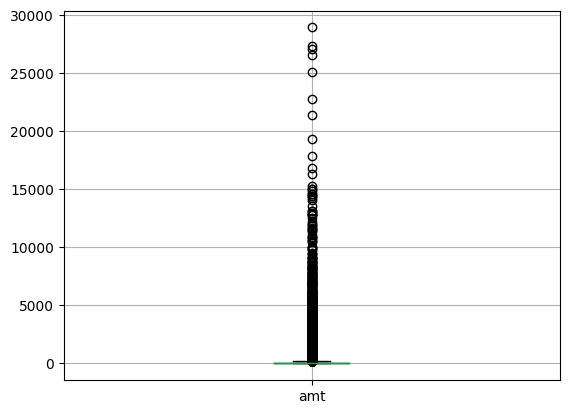

In [ ]:
data[[col_numeric[1]]].boxplot()

<Axes: >

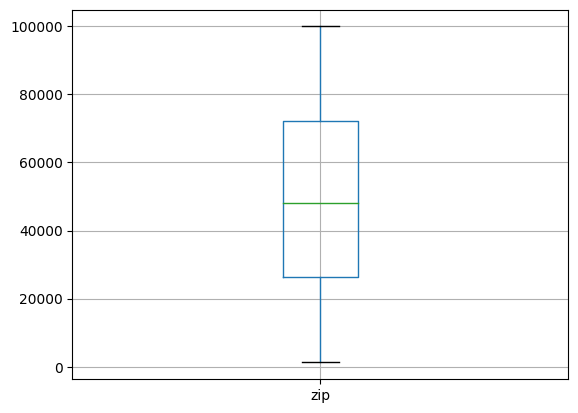

In [ ]:
data[[col_numeric[2]]].boxplot()

Lattitude Longitude

<Axes: >

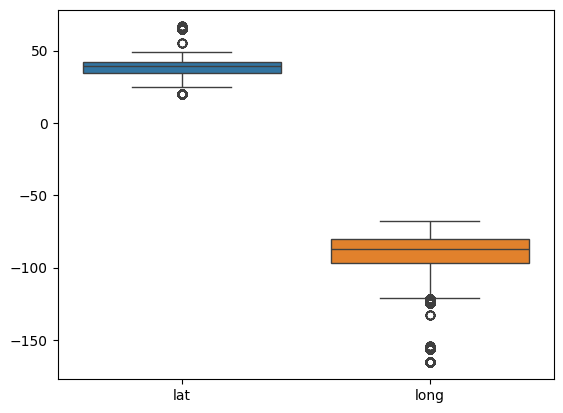

In [ ]:
sns.boxplot(data=data[col_numeric[3:5]], orient='v')

In [ ]:
pip install matplotlib basemap

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 936.0/936.0 kB 24.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 30.5/30.5 MB 32.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 53.0/53.0 kB 4.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 8.3/8.3 MB 99.9 MB/s eta 0:00:00
  Attempting uninstall: pyproj
    Found existing installation: pyproj 3.7.0
    Uninstalling pyproj-3.7.0:
      Successfully uninstalled pyproj-3.7.0
  Attempting uninstall: packaging
    Found existing installation: packaging 24.1
    Uninstalling packaging-24.1:
      Successfully uninstalled packaging-24.1


In [ ]:
# @title Default title text
import matplotlib.pyplot as plt
from mpl_toolkits.basemap import Basemap
import numpy as np
import random
%matplotlib inline

In [ ]:
location = data[['lat','long']].drop_duplicates().to_numpy()

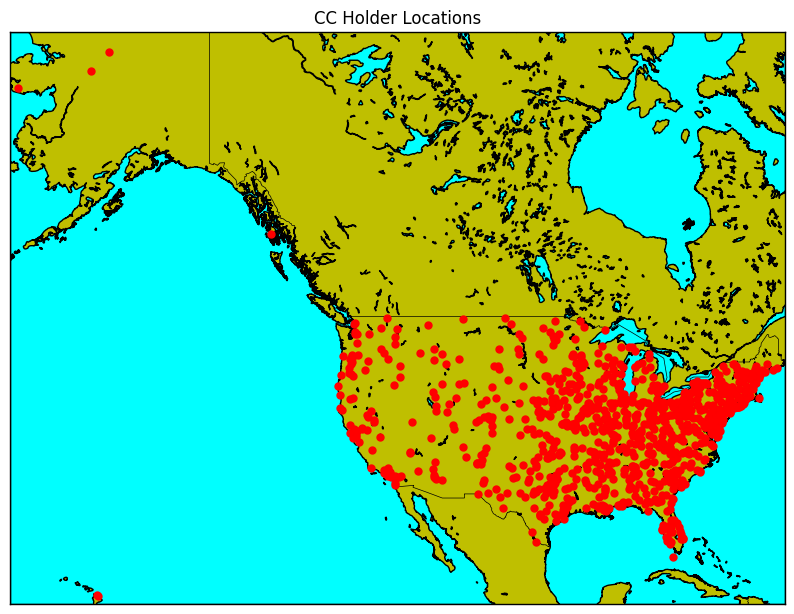

In [ ]:
# @title Default title text
fig = plt.figure(figsize=(10, 8))
m = Basemap(projection='merc', llcrnrlat=data['lat'].min()-1, urcrnrlat=data['lat'].max()+1, llcrnrlon=data['long'].min()-1, urcrnrlon=data['long'].max()+1, resolution='i')

m.drawcoastlines()
m.drawcountries()
m.drawmapboundary(fill_color='aqua')  # Batas peta dengan warna latar belakang air
m.fillcontinents(color='y', lake_color='aqua')  # Warna daratan
#m.drawparallels(range(-90, 90, 10), labels=[1, 0, 0, 0])
#m.drawmeridians(range(-180, 180, 10), labels=[0, 0, 0, 1])

for point in location:
    lat = point[0]
    lon = point[1]
    x, y = m(lon, lat)
    plt.plot(x, y, 'ro', markersize=5)
plt.title('CC Holder Locations')
plt.show()

<Axes: >

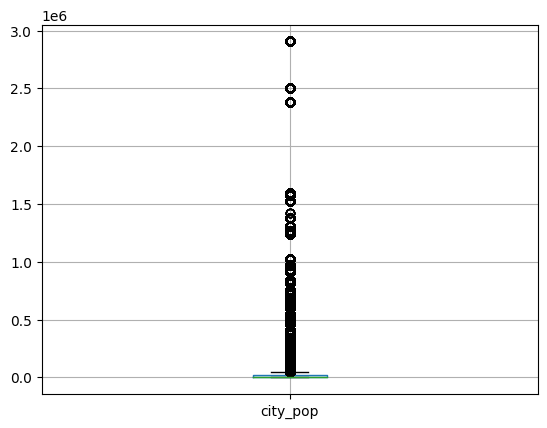

In [ ]:
data[[col_numeric[5]]].boxplot()

**Lokasi Merchants**

<Axes: >

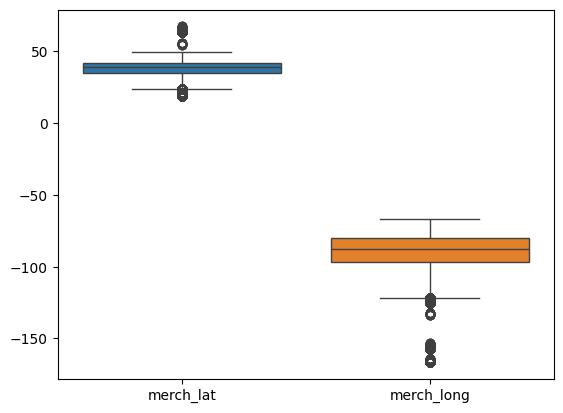

In [ ]:
import seaborn as sns
sns.boxplot(data=data[col_numeric[6:8]], orient='v')

In [ ]:
# @title Default title text
def find_outliers(data, col_names):
  Q1 = data[col_names].quantile(0.25)  # Kuartil pertama (Q1)
  Q3 = data[col_names].quantile(0.75)  # Kuartil ketiga (Q3)
  IQR = Q3 - Q1  # Rentang antar kuartil (IQR)

  lower_bound = Q1 - 1.5 * IQR  # Batas bawah
  upper_bound = Q3 + 1.5 * IQR  # Batas atas

  # Outliers adalah nilai di luar batas bawah dan atas
  outliers = data[(data[col_names] < lower_bound) | (data[col_names] > upper_bound)]
  return outliers
col = ['merch_lat','merch_long']
loc_merch_out = pd.concat([find_outliers(data,col[0])[col],find_outliers(data,col[1])[col]]).drop_duplicates().to_numpy()

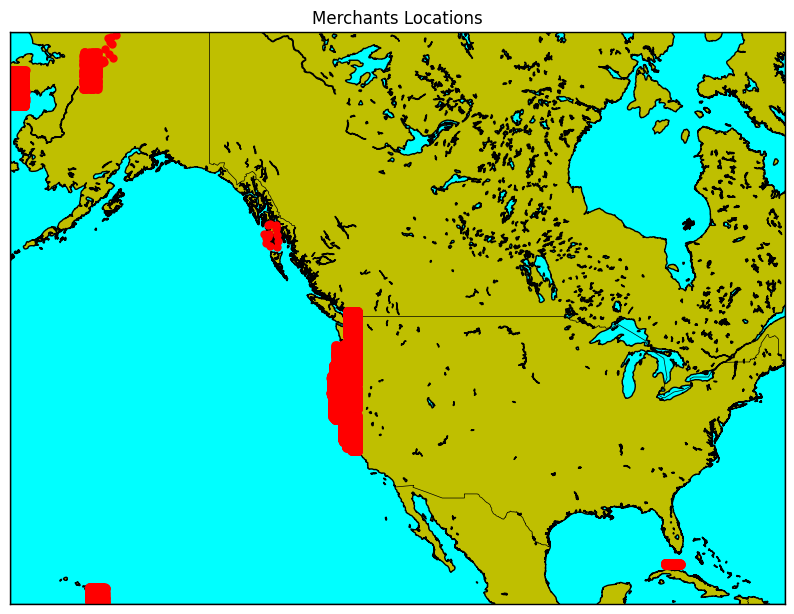

In [ ]:
# @title Default title text
fig = plt.figure(figsize=(10, 8))
m = Basemap(projection='merc', llcrnrlat=data['lat'].min()-1, urcrnrlat=data['lat'].max()+1, llcrnrlon=data['long'].min()-1, urcrnrlon=data['long'].max()+1, resolution='i')

m.drawcoastlines()
m.drawcountries()
m.drawmapboundary(fill_color='aqua')  # Batas peta dengan warna latar belakang air
m.fillcontinents(color='y', lake_color='aqua')  # Warna daratan
#m.drawparallels(range(-90, 90, 10), labels=[1, 0, 0, 0])
#m.drawmeridians(range(-180, 180, 10), labels=[0, 0, 0, 1])

for point in loc_merch_out:
    lat = point[0]
    lon = point[1]
    x, y = m(lon, lat)
    plt.plot(x, y, 'ro', markersize=5)
plt.title('Merchants Locations')
plt.show()

### **Encoding Data Kategorical**

Hanya ada tiga data kategorikal yaitu `category`,`cc_num`, dan `zip`

#### **category**

Karena atribut pada feature `category` tidak memiliki informasi level atau tingkatan maka akan menggunakan one hot encoding.

In [ ]:
category_ = pd.get_dummies(data['category']).astype(int)

In [ ]:
category_.head()

,entertainment,food_dining,gas_transport,grocery_net,grocery_pos,health_fitness,home,kids_pets,misc_net,misc_pos,personal_care,shopping_net,shopping_pos,travel
0,0,0,0,0,1,0,0,0,0,0,0,0,0,0
1,0,0,0,0,1,0,0,0,0,0,0,0,0,0
2,0,0,1,0,0,0,0,0,0,0,0,0,0,0
3,0,0,0,0,0,0,1,0,0,0,0,0,0,0
4,0,0,0,1,0,0,0,0,0,0,0,0,0,0


In [ ]:
data=pd.concat([data, category_], axis =1)
#data=pd.merge(data,category_, left_index=True,right_index=True)#how='inner')

In [ ]:
data = data.drop(columns=['category'])

In [ ]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1852374 entries, 0 to 1852373
Data columns (total 38 columns):
 #   Column                 Dtype  
---  ------                 -----  
 0   level_0                int64  
 1   index                  int64  
 2   Unnamed: 0             int64  
 3   trans_date_trans_time  object 
 4   cc_num                 int64  
 5   merchant               object 
 6   amt                    float64
 7   first                  object 
 8   last                   object 
 9   gender                 object 
 10  street                 object 
 11  city                   object 
 12  state                  object 
 13  zip                    int64  
 14  lat                    float64
 15  long                   float64
 16  city_pop               int64  
 17  job                    object 
 18  dob                    object 
 19  trans_num              object 
 20  unix_time              int64  
 21  merch_lat              float64
 22  merch_long        

#### **cc_num**

Akan digunakan target encoding

In [ ]:
encoder=LabelEncoder()
#data['category']=encoder.fit_transform(data['category'])
#encoder.classes_

In [ ]:
weight= {}
cc_num_unique = data['cc_num'].unique().tolist()
for val in cc_num_unique:
  cc_num_i = data[data['cc_num']==val][['is_fraud']]
  weight[val] = cc_num_i.sum().values[0]/len(cc_num_i)
def TargetEncode(x):
  for val in cc_num_unique:
    if x==val:
      return weight[val]

In [ ]:
data['cc_num']= data['cc_num'].apply(TargetEncode)

In [ ]:
data.head(3)

,level_0,index,Unnamed: 0,trans_date_trans_time,cc_num,merchant,amt,first,last,gender,...,grocery_pos,health_fitness,home,kids_pets,misc_net,misc_pos,personal_care,shopping_net,shopping_pos,travel
0,396515,396515,396515,2019-06-30 04:10:10,0.006367,fraud_Kunze Inc,194.03,Jennifer,Bishop,F,...,1,0,0,0,0,0,0,0,0,0
1,777124,777124,777124,2019-11-29 08:45:55,0.005005,"fraud_Osinski, Ledner and Leuschke",110.93,Jason,Mcmahon,M,...,1,0,0,0,0,0,0,0,0,0
2,1013121,1013121,1013121,2020-02-22 04:31:03,0.004105,fraud_Corwin-Collins,43.70,Teresa,Stein,F,...,0,0,0,0,0,0,0,0,0,0


#### **Kode `zip`**

Kode `zip` menyatakan kode pos untuk suatu wilayah di amerika serikat, berikut aturan pembuatan kode pos di amerika serikat:
 - Digit Pertama: Menunjukkan wilayah besar secara geografis. Amerika Serikat dibagi menjadi 10 wilayah, di mana angka pertama kode pos (0 hingga 9) menunjukkan lokasi geografis besar. Misalnya:

    - Angka 0 untuk timur laut (New England).
    - Angka 9 untuk pantai barat.

 - Dua Digit Berikutnya: Mewakili area yang lebih kecil, biasanya meliputi kota-kota atau bagian-bagian utama negara bagian.

 - Dua Digit Terakhir: Menentukan lokasi yang lebih spesifik seperti kantor pos lokal atau zona pengiriman tertentu.
 - Digit pertama dari kode pos di Amerika Serikat diurutkan dari timur ke barat. Kode pos dengan angka pertama yang lebih kecil (seperti 0 dan 1) umumnya berada di wilayah timur laut, dan kode pos dengan angka pertama yang lebih besar (seperti 8 dan 9) berada di wilayah barat.

 - Berikut adalah pembagian wilayah berdasarkan digit pertama kode pos:

    - 0: Bagian timur laut, termasuk negara bagian seperti New York, New Jersey, dan New England.
    - 1: Pennsylvania, Delaware, dan sebagian negara bagian di sekitarnya.
    - 2: Wilayah timur tengah seperti Washington, D.C., Virginia, dan Maryland.
    - 3: Bagian tenggara seperti Georgia, Florida, dan Alabama.
    - 4: Michigan, Ohio, Kentucky, dan wilayah sekitarnya.
    - 5: Illinois, Missouri, Nebraska, dan Iowa.
    - 6: Negara bagian tengah seperti Texas dan beberapa bagian selatan.
    - 7: Negara bagian di barat tengah dan bagian selatan seperti Oklahoma dan Colorado.
    - 8: Negara bagian barat seperti Nevada, Arizona, dan Utah.
    - 9: Pantai barat, termasuk California, Oregon, dan

Oleh Karena itu encoding yang dilakukan pada kode `Zip` menggunakan ordinal encoding, sesuai dengan wilayah amerika serikat. Nilainya dari 0 s.d 9, semakin kecil nilainya wilayahnya akan semaikin ke timur.

In [ ]:
def ZipEncode(x):
  return x//10000
data['zip']=data['zip'].apply(ZipEncode)

## **Feature Engineering**

### `trans_date_trans_time`

Perlu dilakukan aksi pada feature waktu transaksi sehingga mungkin bisa melihat kebiasaan si pelaku melakukan penipuan

In [ ]:
# @title Default title text
data['trans_date_trans_time']=pd.to_datetime(data['trans_date_trans_time'])
data['trans_day']=data['trans_date_trans_time'].dt.day
data['trans_month']=data['trans_date_trans_time'].dt.month
data['trans_year']=data['trans_date_trans_time'].dt.year
data['trans_hour']=data['trans_date_trans_time'].dt.hour
data['trans_minute']=data['trans_date_trans_time'].dt.minute
data.drop(columns=['trans_date_trans_time'],inplace=True)

In [ ]:
data.head(3)

,level_0,index,Unnamed: 0,cc_num,merchant,amt,first,last,gender,street,...,misc_pos,personal_care,shopping_net,shopping_pos,travel,trans_day,trans_month,trans_year,trans_hour,trans_minute
0,396515,396515,396515,0.006367,fraud_Kunze Inc,194.03,Jennifer,Bishop,F,589 Matthew Brooks,...,0,0,0,0,0,30,6,2019,4,10
1,777124,777124,777124,0.005005,"fraud_Osinski, Ledner and Leuschke",110.93,Jason,Mcmahon,M,6385 Donald Square Suite 429,...,0,0,0,0,0,29,11,2019,8,45
2,1013121,1013121,1013121,0.004105,fraud_Corwin-Collins,43.70,Teresa,Stein,F,2838 White Fields Apt. 473,...,0,0,0,0,0,22,2,2020,4,31


## **Similarity Checking**

In [ ]:
data.head()

,cc_num,amt,zip,lat,long,city_pop,merch_lat,merch_long,is_fraud,entertainment,...,misc_pos,personal_care,shopping_net,shopping_pos,travel,trans_day,trans_month,trans_year,trans_hour,trans_minute
0,0.006367,194.03,7,29.7972,-95.3288,2906700,30.056677,-95.009428,0,0,...,0,0,0,0,0,30,6,2019,4,10
1,0.005005,110.93,2,38.8029,-77.2116,104396,38.628199,-77.269292,0,0,...,0,0,0,0,0,29,11,2019,8,45
2,0.004105,43.70,2,32.9413,-81.1807,1725,33.215780,-80.319983,0,0,...,0,0,0,0,0,22,2,2020,4,31
3,0.009511,83.40,8,41.0552,-110.1603,49,41.867556,-110.170774,0,0,...,0,0,0,0,0,2,7,2020,20,30
4,0.001921,63.30,2,36.2017,-81.1286,21134,36.309549,-81.525285,0,0,...,0,0,0,0,0,15,11,2020,1,59


In [ ]:
data.describe().T

,count,mean,std,min,25%,50%,75%,max
cc_num,1852374.0,0.005205,0.022238,0.000000,0.002739,0.003830,0.005467,1.000000e+00
amt,1852374.0,70.062234,159.252341,1.000000,9.640000,47.450000,83.100000,2.894890e+04
zip,1852374.0,4.366469,2.679399,0.000000,2.000000,4.000000,7.000000,9.000000e+00
lat,1852374.0,38.539299,5.071440,20.027100,34.668900,39.354300,41.940400,6.669330e+01
long,1852374.0,-90.227769,13.747792,-165.672300,-96.798000,-87.476900,-80.158000,-6.795030e+01
city_pop,1852374.0,88643.575971,301488.336898,23.000000,741.000000,2443.000000,20328.000000,2.906700e+06
merch_lat,1852374.0,38.538966,5.105576,19.027422,34.740122,39.368905,41.956259,6.751027e+01
merch_long,1852374.0,-90.227876,13.759590,-166.671575,-96.899411,-87.440674,-80.245060,-6.695090e+01
is_fraud,1852374.0,0.005205,0.071955,0.000000,0.000000,0.000000,0.000000,1.000000e+00
entertainment,1852374.0,0.072403,0.259155,0.000000,0.000000,0.000000,0.000000,1.000000e+00


In [ ]:
data_X = data.drop(columns='is_fraud')
data_y = data['is_fraud']
data_mean = data_X.mean()
data_std = data_X.std()
data_norm = (data_X-data_mean)/data_std

In [ ]:
data_norm.describe().T

,count,mean,std,min,25%,50%,75%,max
cc_num,1852374.0,2.697945e-17,1.0,-0.234044,-0.110886,-0.061800,0.011795,44.734080
amt,1852374.0,-3.671502e-16,1.0,-0.433665,-0.379412,-0.141990,0.081869,181.340115
zip,1852374.0,5.846985e-17,1.0,-1.629645,-0.883209,-0.136773,0.982881,1.729317
lat,1852374.0,8.392334e-15,1.0,-3.650285,-0.763176,0.160704,0.670638,5.551481
long,1852374.0,-4.022924e-16,1.0,-5.487756,-0.477912,0.200095,0.732464,1.620440
city_pop,1852374.0,1.528202e-17,1.0,-0.293944,-0.291562,-0.285917,-0.226594,9.347149
merch_lat,1852374.0,-7.592354e-16,1.0,-3.821615,-0.744058,0.162555,0.669326,5.674443
merch_long,1852374.0,-1.148097e-15,1.0,-5.555667,-0.484864,0.202564,0.725517,1.691691
entertainment,1852374.0,2.545997e-17,1.0,-0.279383,-0.279383,-0.279383,-0.279383,3.579318
food_dining,1852374.0,-1.818193e-17,1.0,-0.275556,-0.275556,-0.275556,-0.275556,3.629019


In [ ]:
Data_norm = pd.concat([data_norm, data_y],axis=1)
Data_norm.describe().T

,count,mean,std,min,25%,50%,75%,max
cc_num,1852374.0,2.697945e-17,1.000000,-0.234044,-0.110886,-0.061800,0.011795,44.734080
amt,1852374.0,-3.671502e-16,1.000000,-0.433665,-0.379412,-0.141990,0.081869,181.340115
zip,1852374.0,5.846985e-17,1.000000,-1.629645,-0.883209,-0.136773,0.982881,1.729317
lat,1852374.0,8.392334e-15,1.000000,-3.650285,-0.763176,0.160704,0.670638,5.551481
long,1852374.0,-4.022924e-16,1.000000,-5.487756,-0.477912,0.200095,0.732464,1.620440
city_pop,1852374.0,1.528202e-17,1.000000,-0.293944,-0.291562,-0.285917,-0.226594,9.347149
merch_lat,1852374.0,-7.592354e-16,1.000000,-3.821615,-0.744058,0.162555,0.669326,5.674443
merch_long,1852374.0,-1.148097e-15,1.000000,-5.555667,-0.484864,0.202564,0.725517,1.691691
entertainment,1852374.0,2.545997e-17,1.000000,-0.279383,-0.279383,-0.279383,-0.279383,3.579318
food_dining,1852374.0,-1.818193e-17,1.000000,-0.275556,-0.275556,-0.275556,-0.275556,3.629019


In [ ]:
Data_norm.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1852374 entries, 0 to 1852373
Data columns (total 28 columns):
 #   Column          Dtype  
---  ------          -----  
 0   cc_num          float64
 1   amt             float64
 2   zip             float64
 3   lat             float64
 4   long            float64
 5   city_pop        float64
 6   merch_lat       float64
 7   merch_long      float64
 8   entertainment   float64
 9   food_dining     float64
 10  gas_transport   float64
 11  grocery_net     float64
 12  grocery_pos     float64
 13  health_fitness  float64
 14  home            float64
 15  kids_pets       float64
 16  misc_net        float64
 17  misc_pos        float64
 18  personal_care   float64
 19  shopping_net    float64
 20  shopping_pos    float64
 21  travel          float64
 22  trans_day       float64
 23  trans_month     float64
 24  trans_year      float64
 25  trans_hour      float64
 26  trans_minute    float64
 27  is_fraud        int64  
dtypes: float64(2

In [ ]:
data_0 = Data_norm[Data_norm['is_fraud']==0]
data_1 = Data_norm[Data_norm['is_fraud']==1]

In [ ]:
data_0.iloc[0]

,0
cc_num,0.052247
amt,0.778436
zip,0.982881
lat,-1.723790
long,-0.371044
city_pop,9.347149
merch_lat,-1.661377
merch_long,-0.347507
entertainment,-0.279383
food_dining,-0.275556


In [ ]:
data_1.iloc[1]

,149
cc_num,0.133042
amt,6.212202
zip,-1.629645
lat,0.968542
long,1.363038
city_pop,-0.269376
merch_lat,0.923973
merch_long,1.338043
entertainment,-0.279383
food_dining,-0.275556


In [ ]:
M_data_0 = data_0.to_numpy()
M_data_1 = data_1.to_numpy()

In [ ]:
import time
start= time.time()
corr_ = np.corrcoef(M_data_0[0], M_data_1[0])
end= time.time()
print(f'Estimasi komputasi serial {(end-start)*len(data_0)*len(data_1)/(3600*24*365):4g} Tahun')

Estimasi komputasi serial 0.630197 Tahun


In [ ]:
N = 5 #Banyak simulasi
m=100
for i in range (N):
  data_0_= data_0.sample(m)
  data_1_= data_1.sample(m)
  M_data_0 = data_0_.to_numpy()
  M_data_1 = data_1_.to_numpy()
  cor = 0
  sim = [[] for i in range(m)]
  for i,d1 in enumerate(M_data_1):
    sim_sum =0
    for d2 in M_data_0:
      corr_ = np.corrcoef(d1,d2)
      if corr_[0,1]>= 0.2:
        cor +=1
        sim_sum+=1
        sim[i].append(d2.tolist())
  print(f'Pola data yang yang berkorelasi kurang dari {0.2} pada simulasi ke-{i+1}: {100*(1-cor/(m**2))} %')

Pola data yang yang berkorelasi kurang dari 0.2 pada simulasi ke-100: 89.71000000000001 %
Pola data yang yang berkorelasi kurang dari 0.2 pada simulasi ke-100: 90.39 %
Pola data yang yang berkorelasi kurang dari 0.2 pada simulasi ke-100: 89.05 %
Pola data yang yang berkorelasi kurang dari 0.2 pada simulasi ke-100: 91.12 %
Pola data yang yang berkorelasi kurang dari 0.2 pada simulasi ke-100: 89.68 %


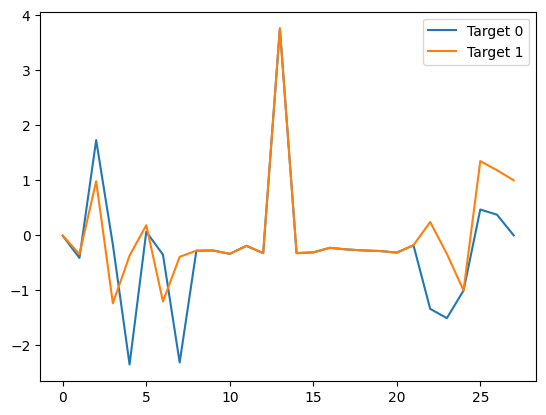

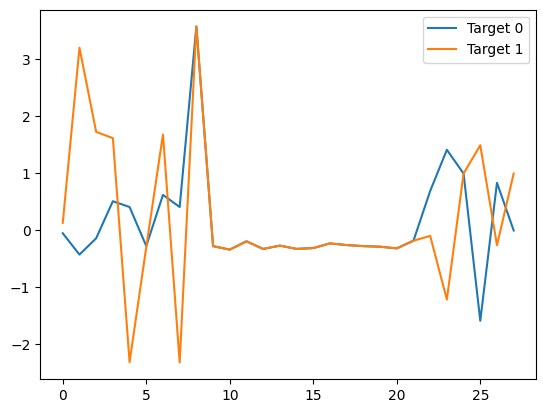

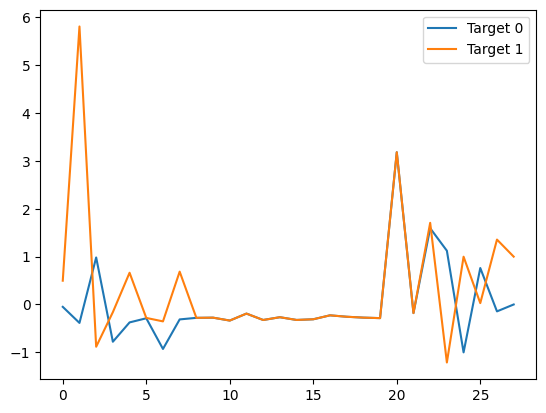

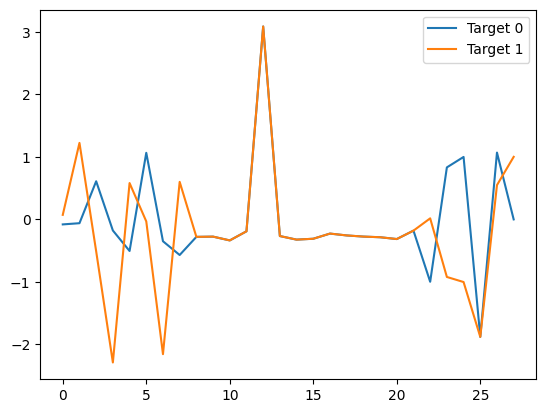

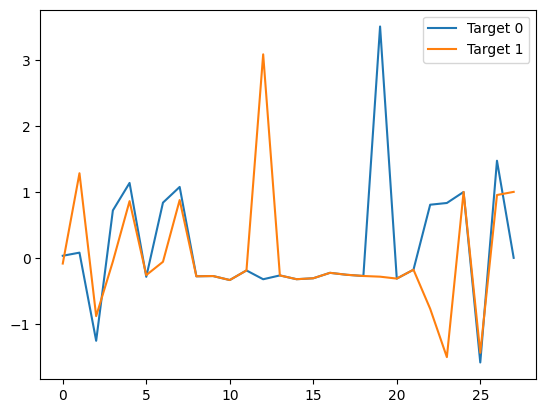

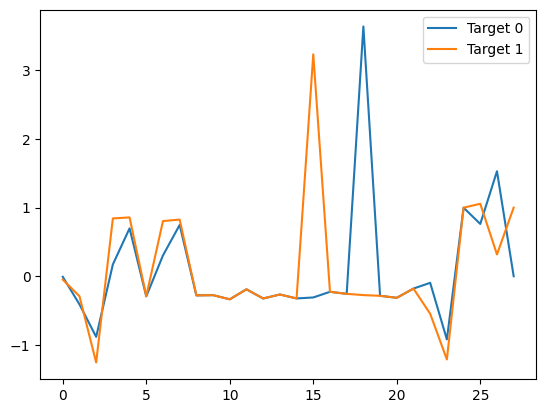

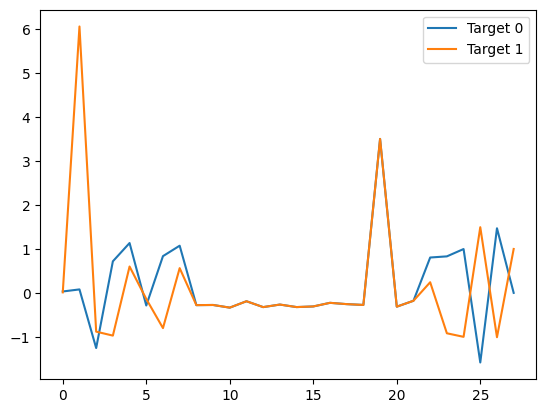

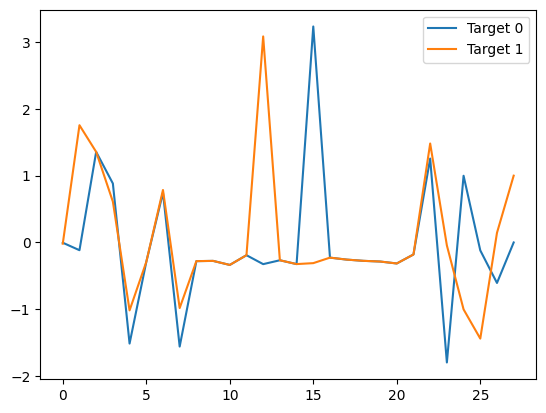

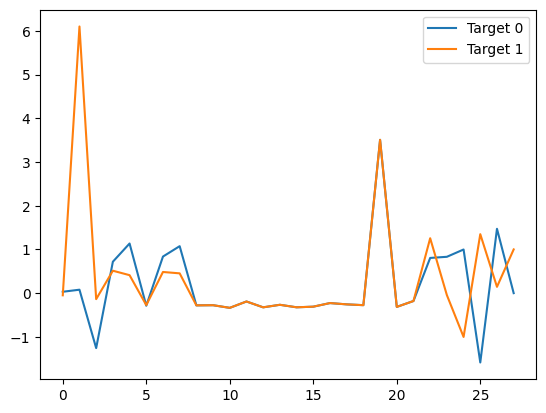

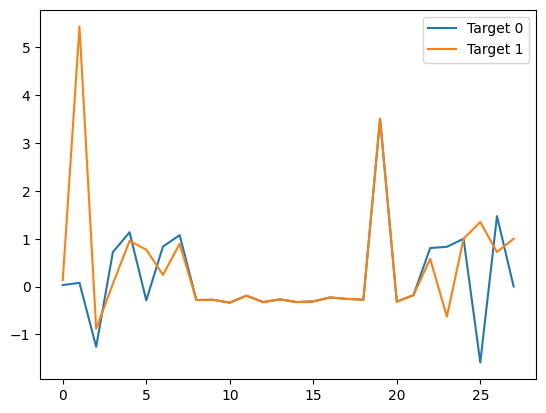

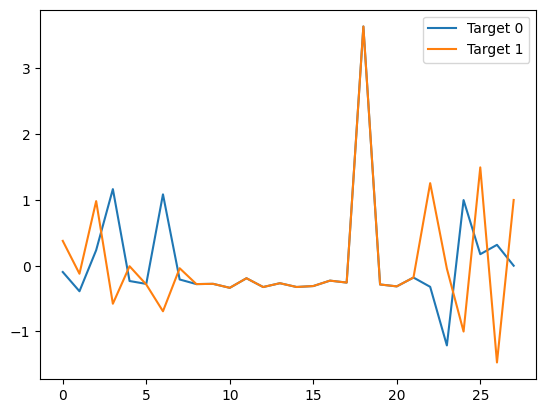

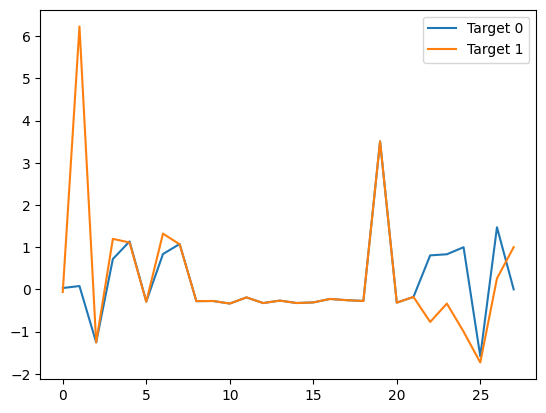

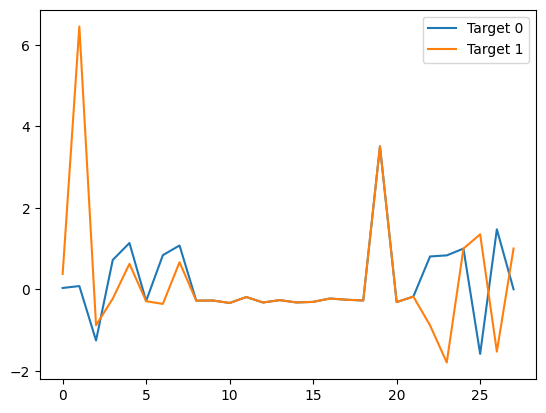

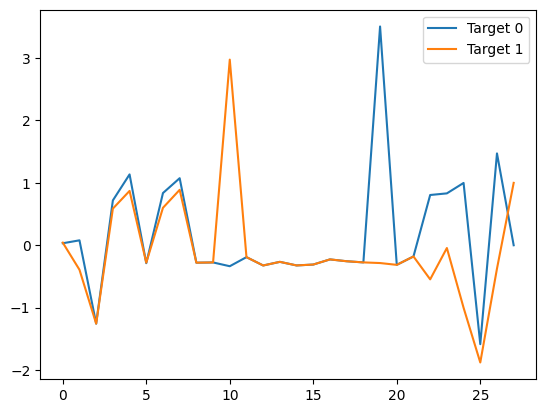

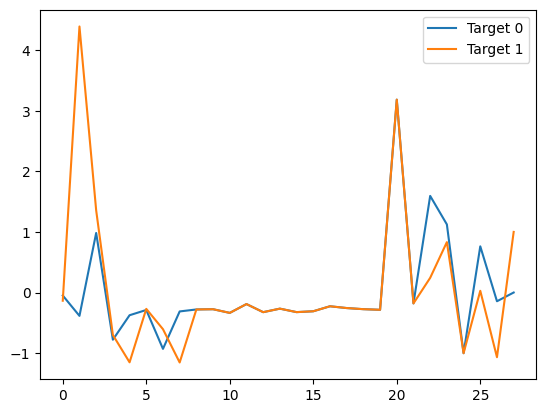

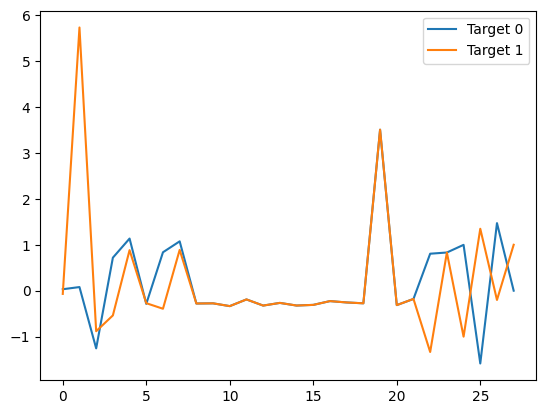

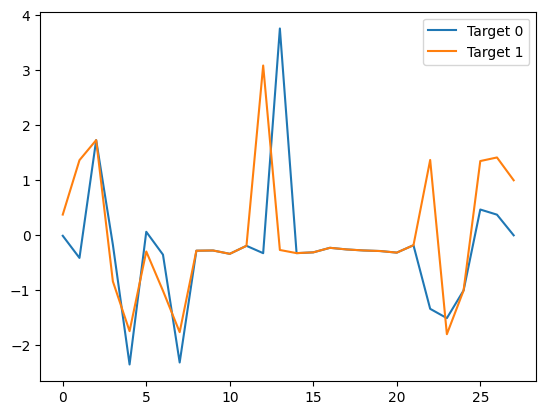

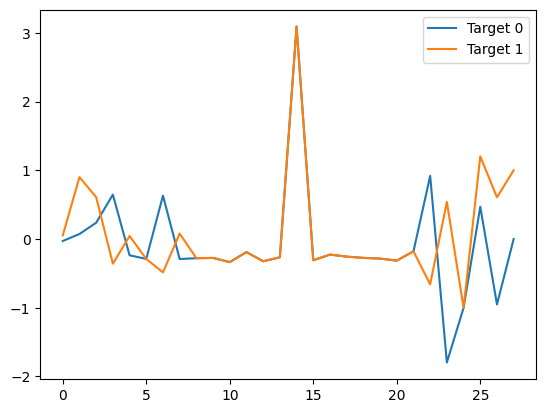

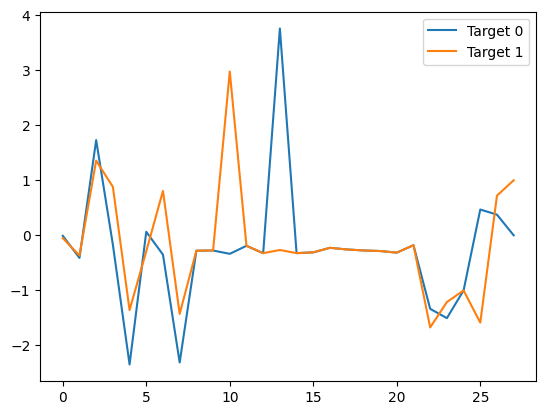

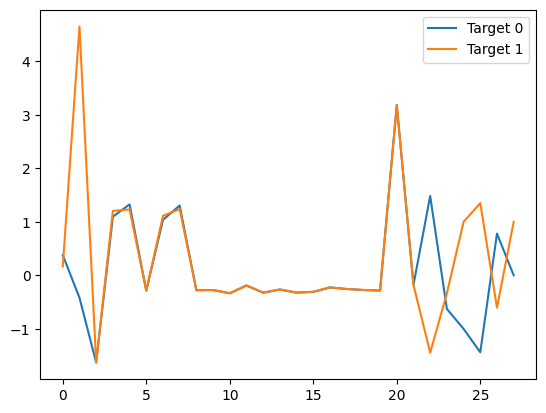

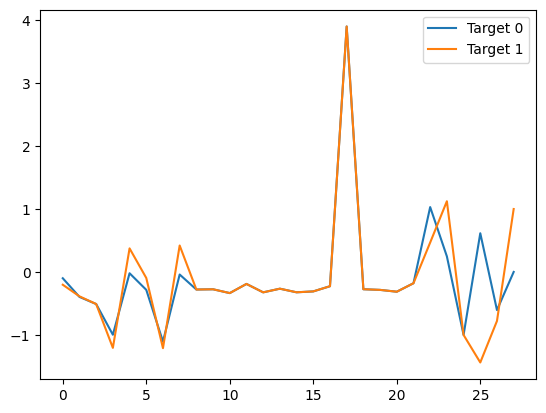

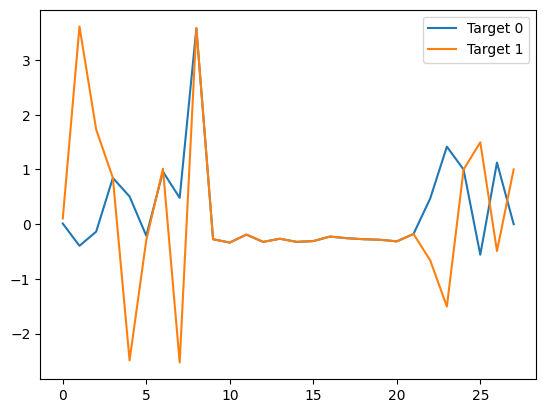

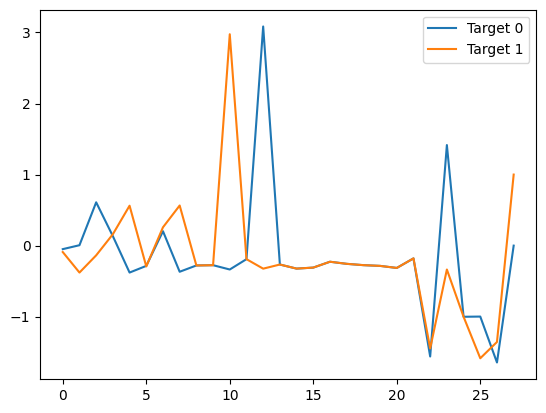

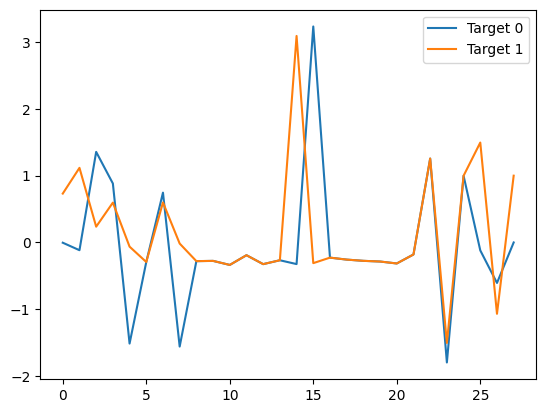

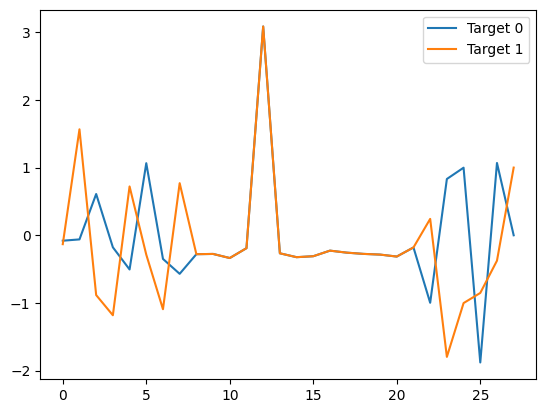

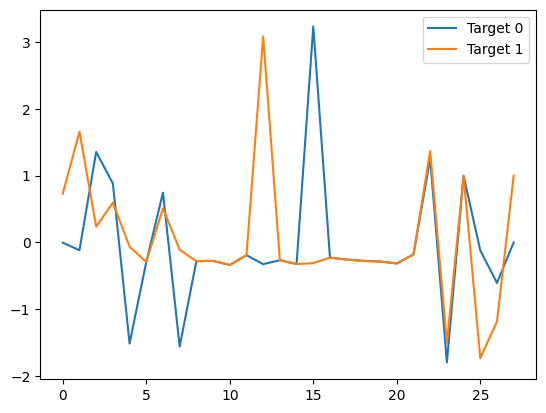

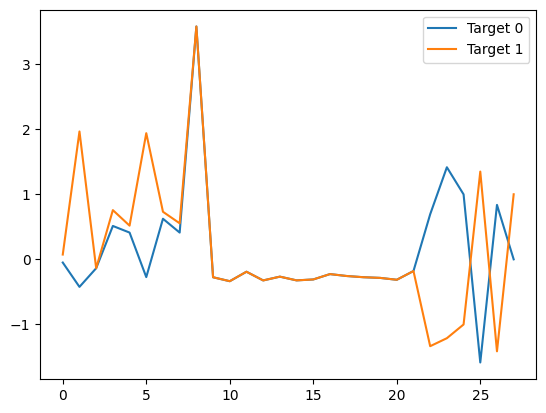

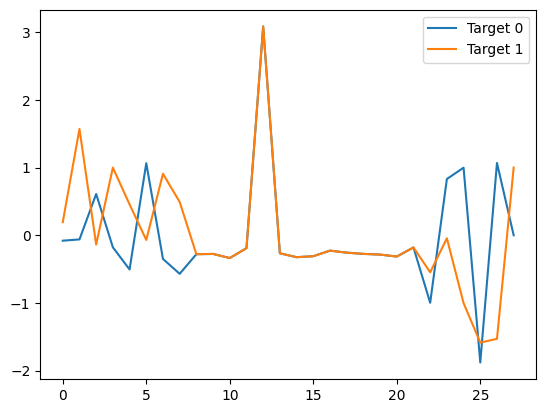

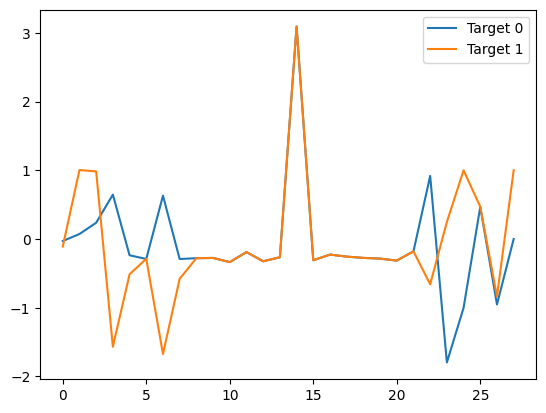

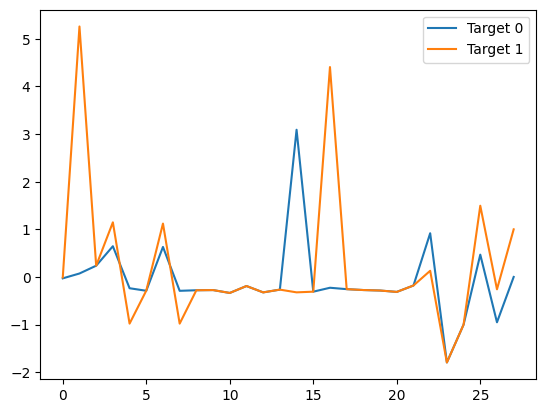

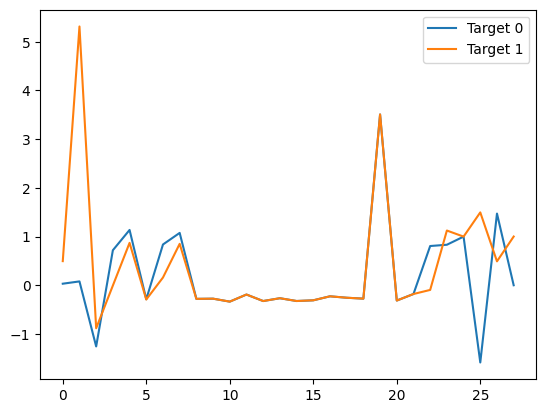

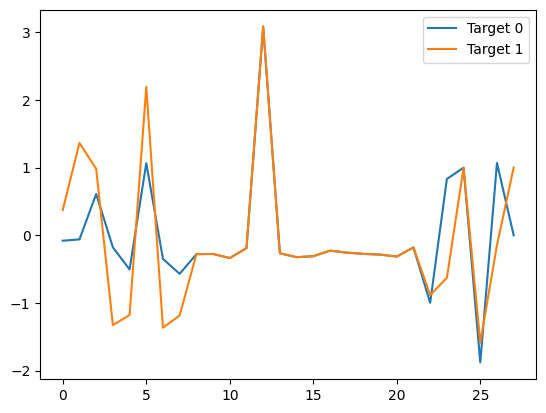

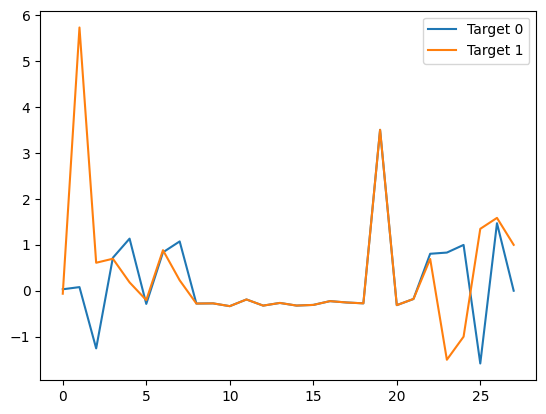

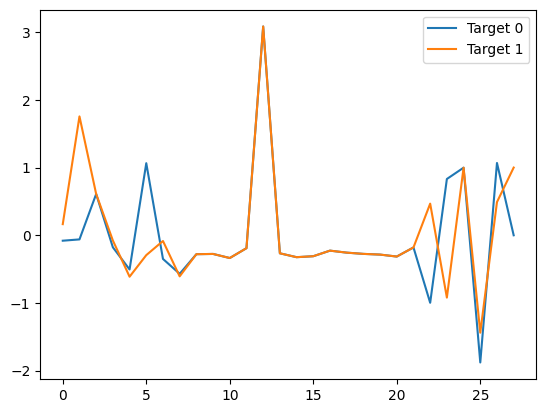

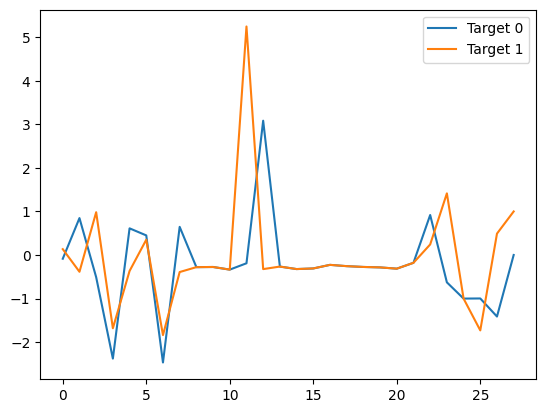

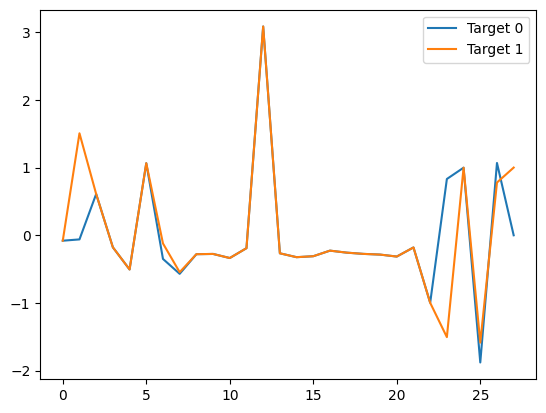

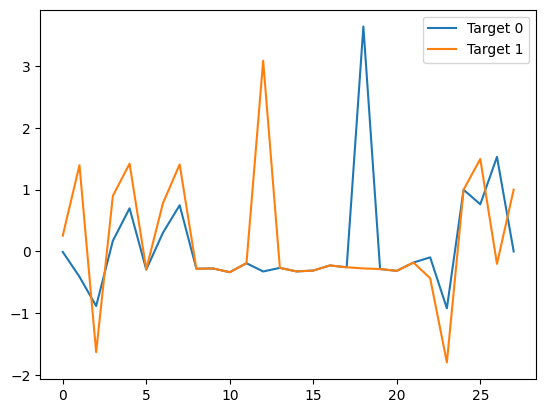

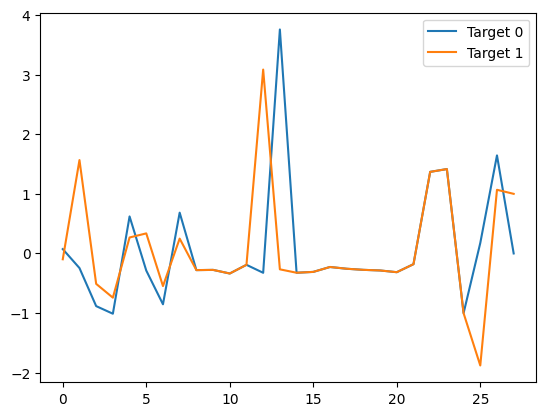

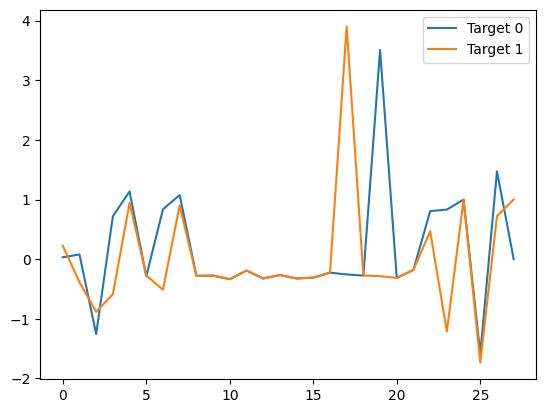

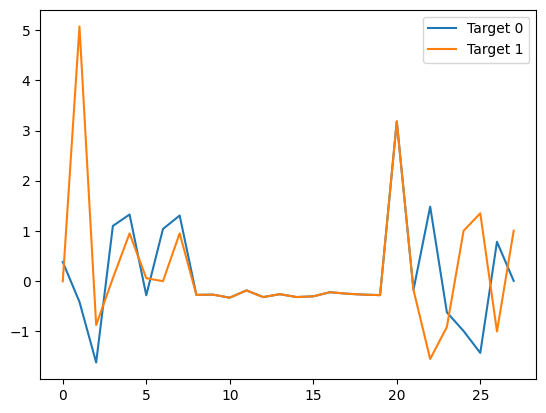

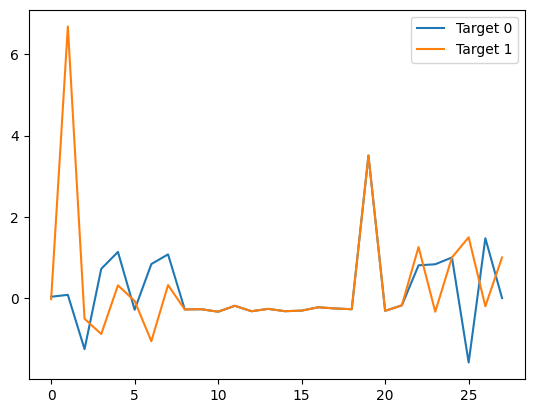

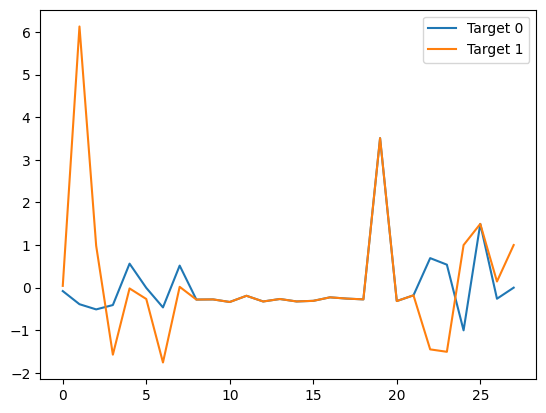

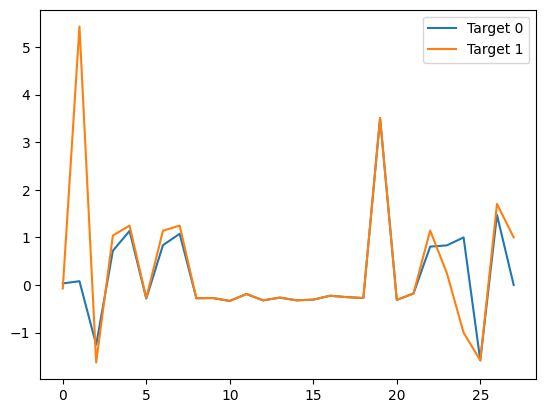

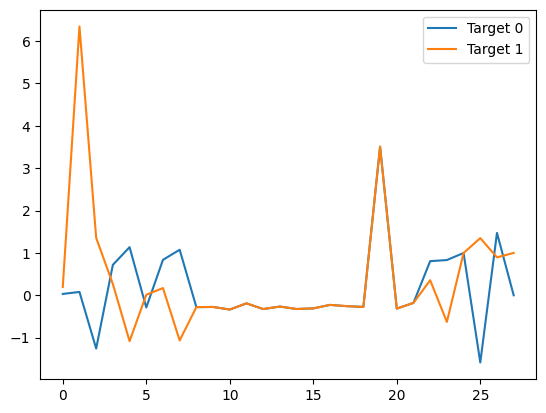

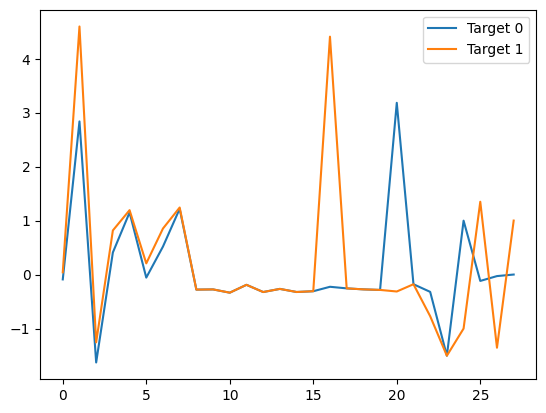

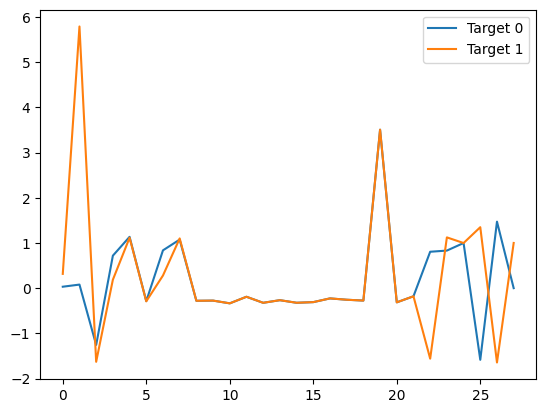

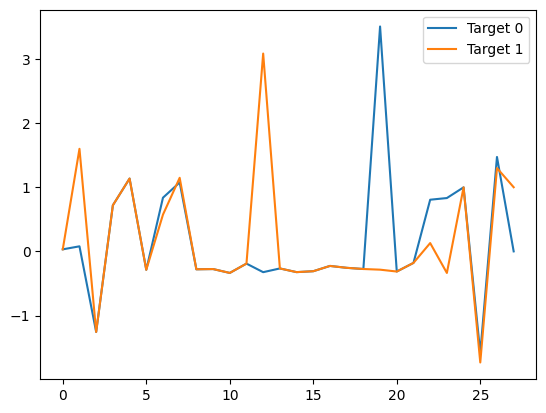

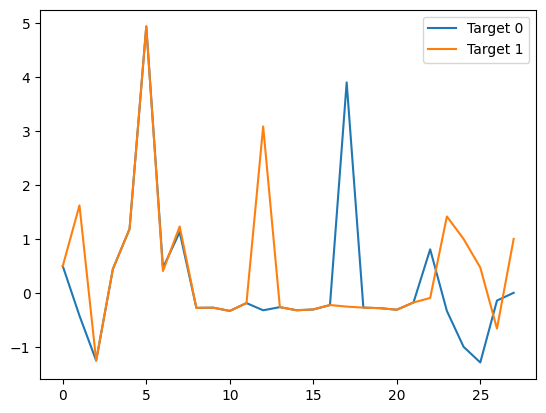

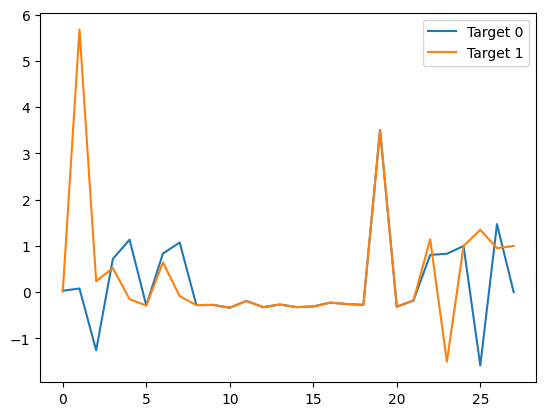

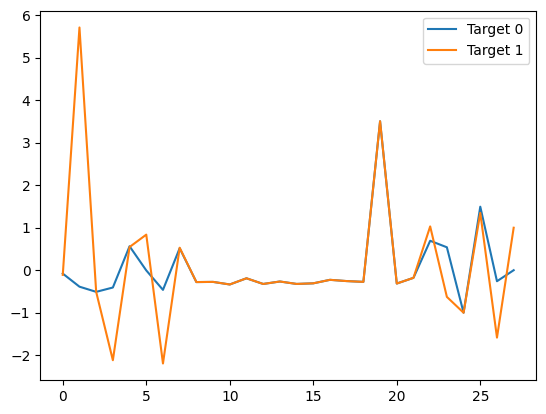

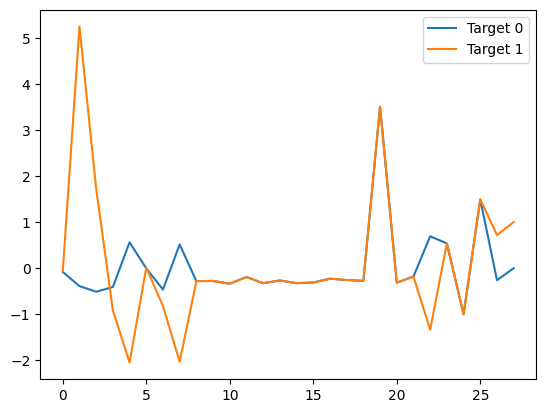

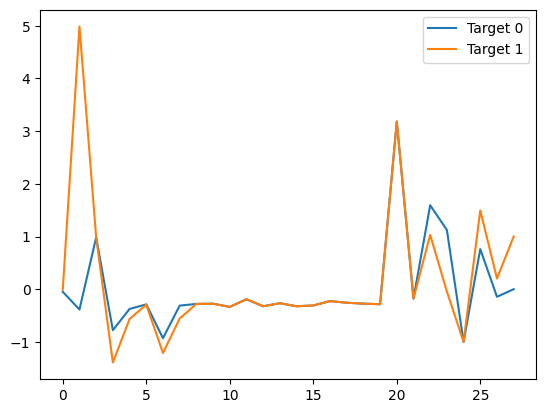

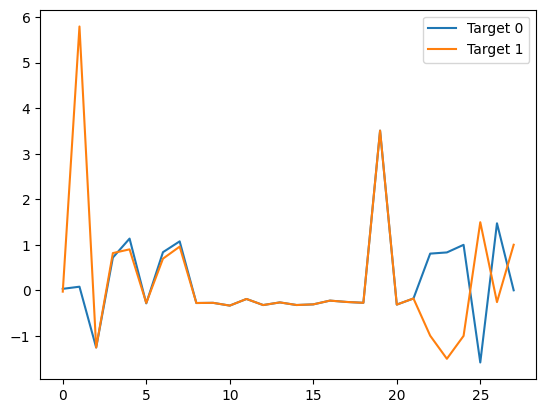

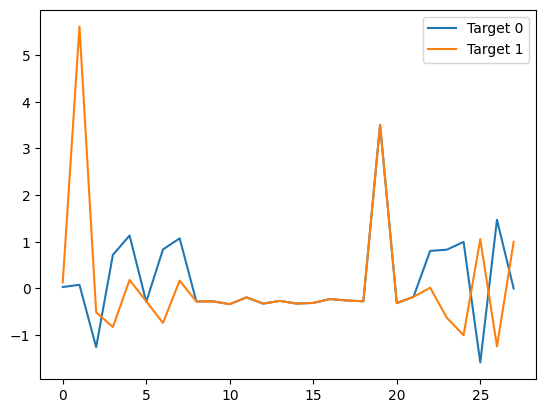

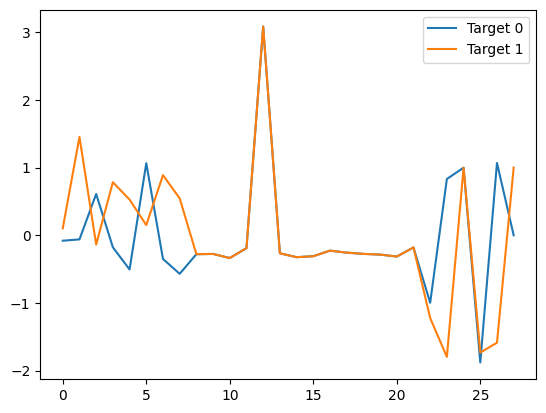

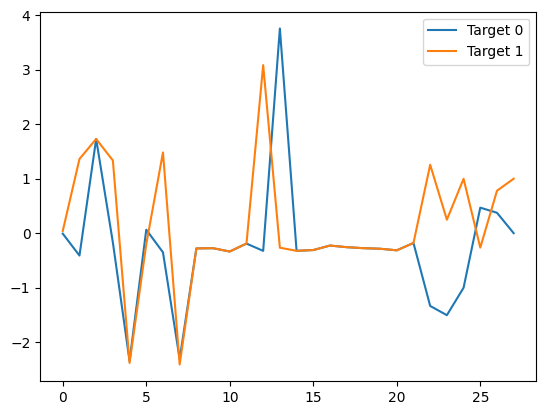

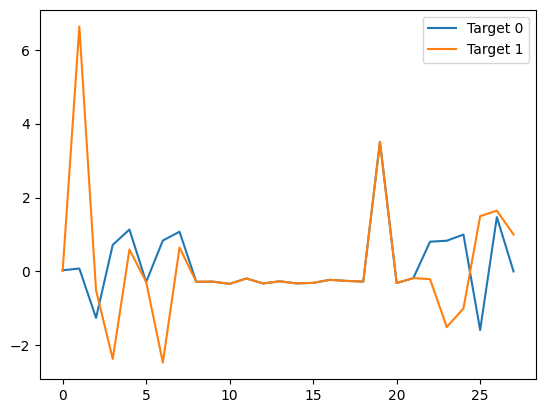

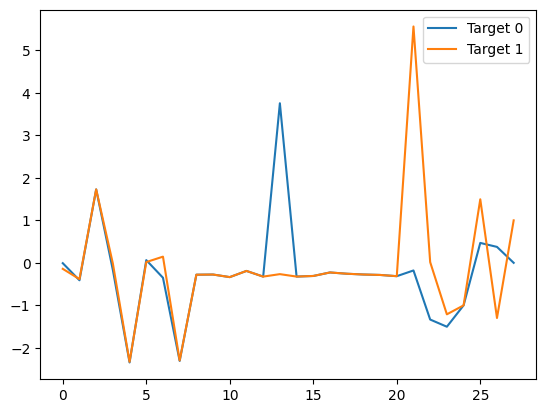

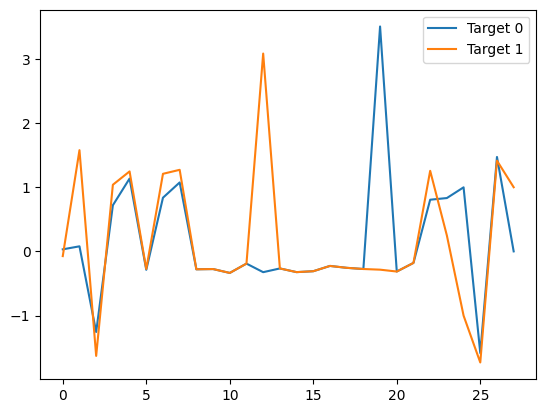

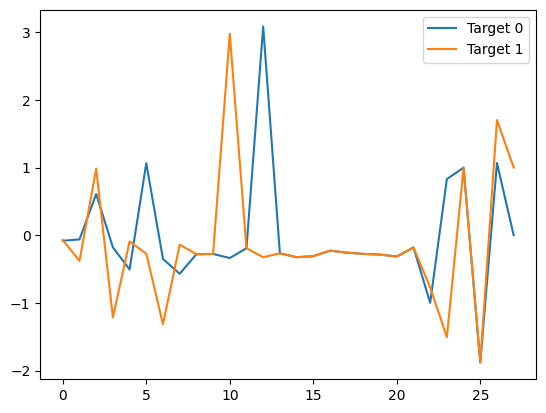

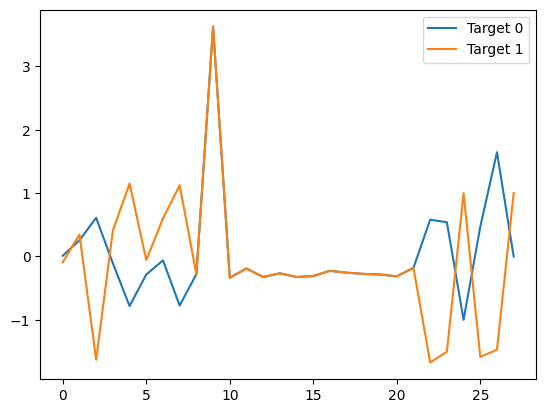

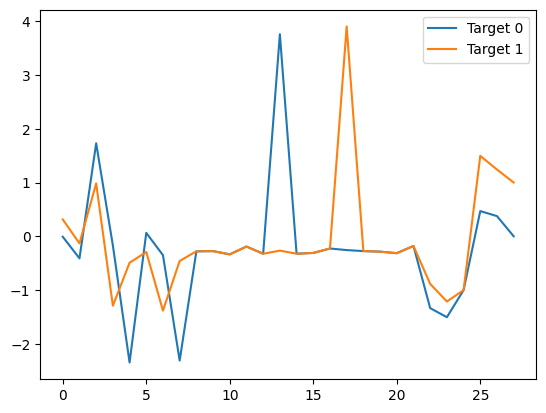

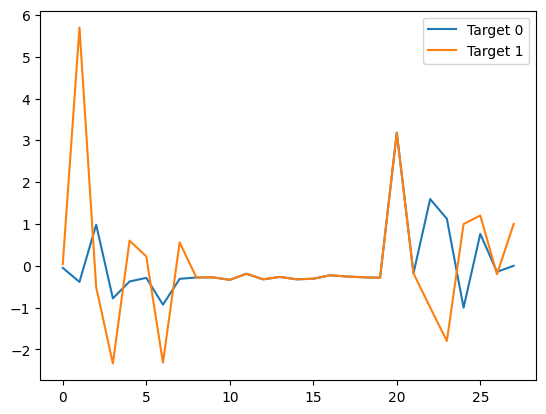

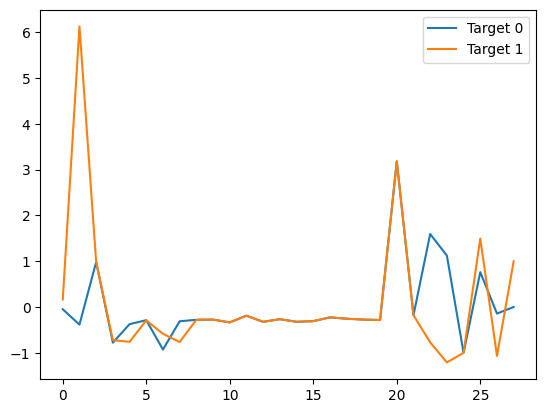

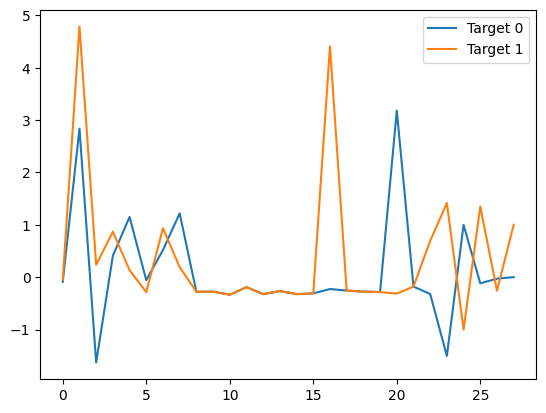

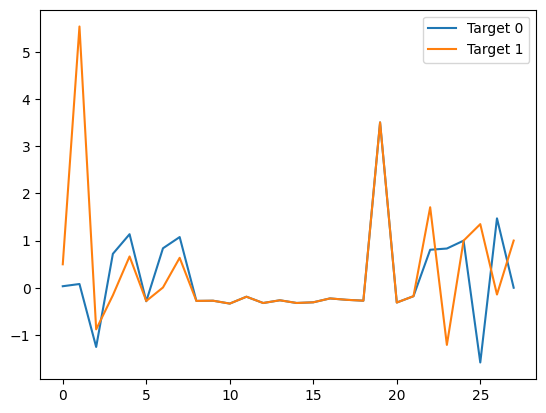

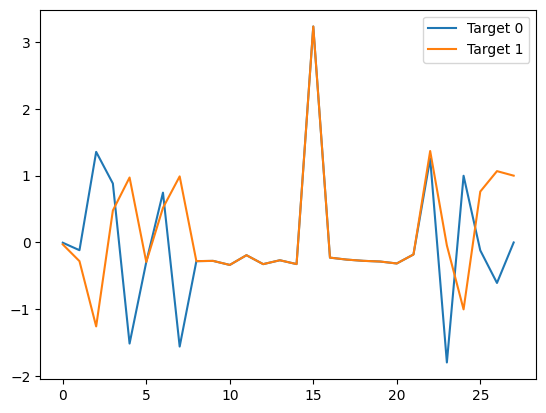

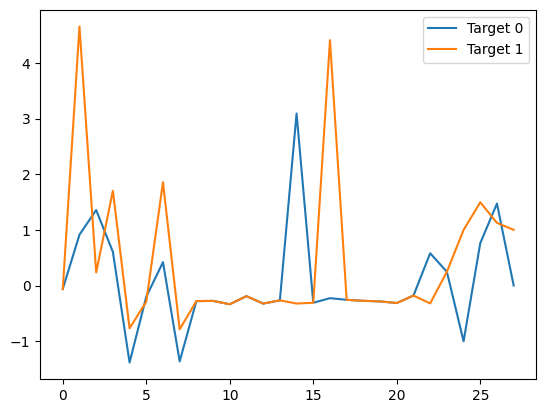

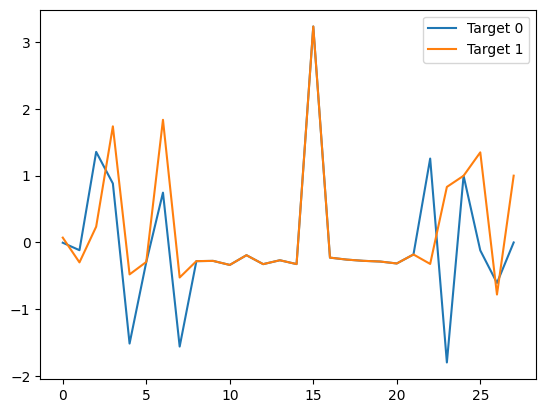

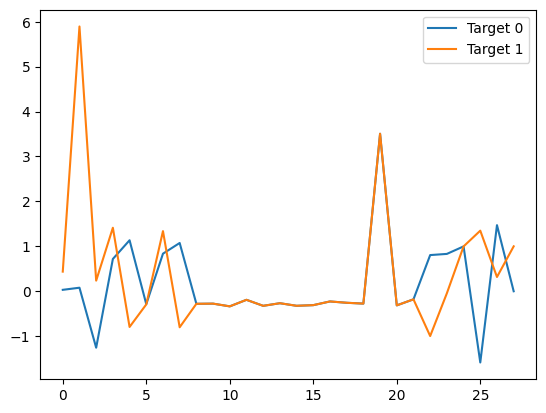

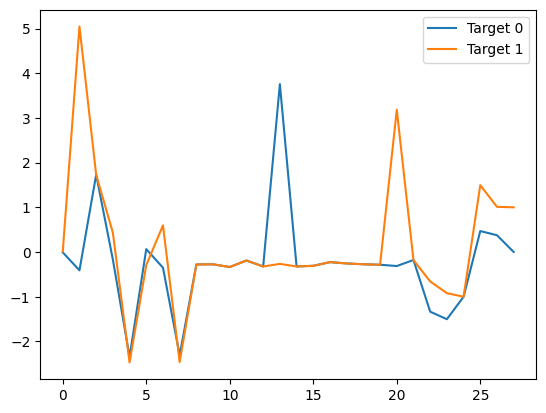

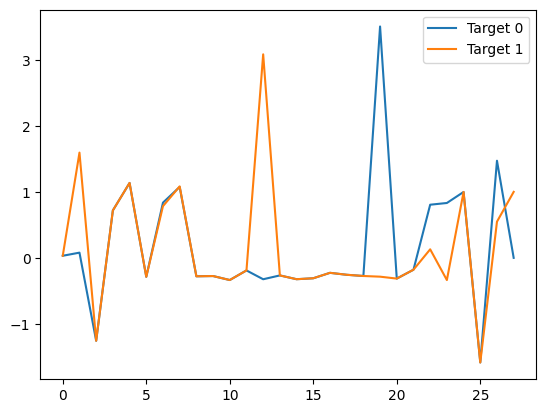

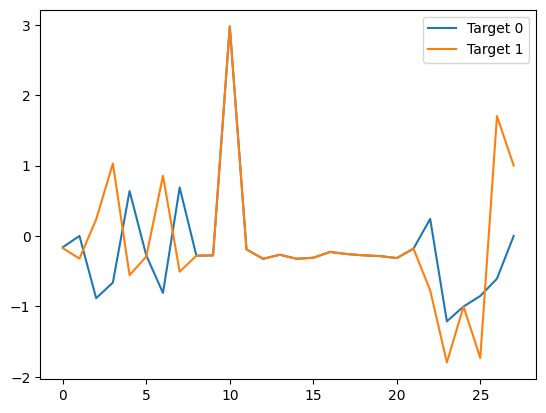

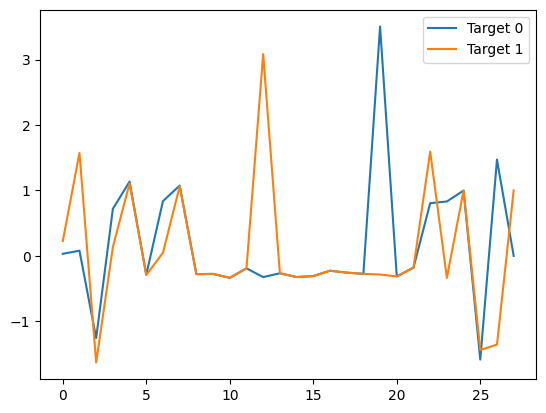

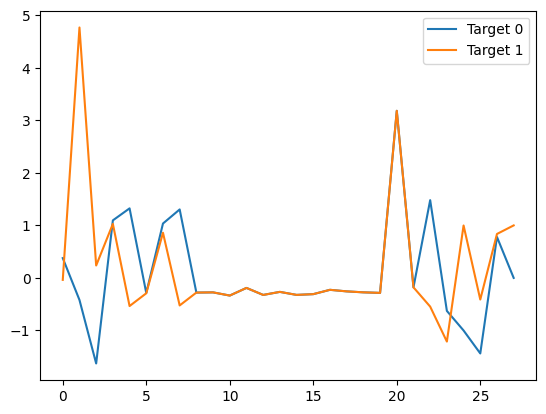

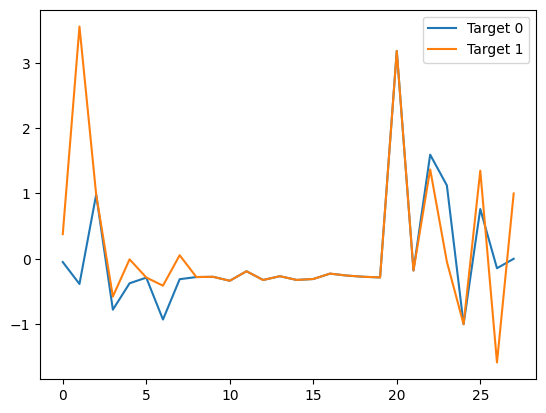

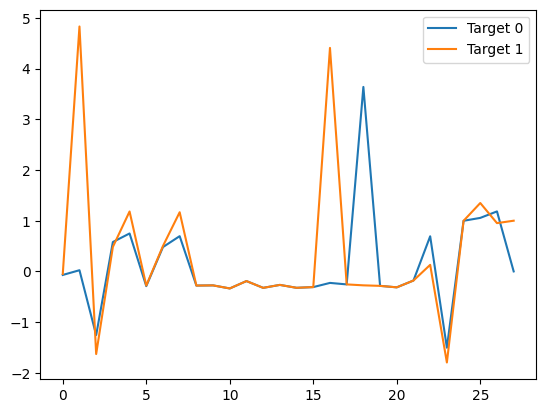

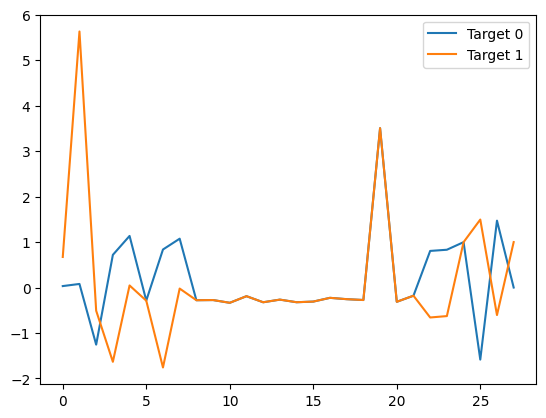

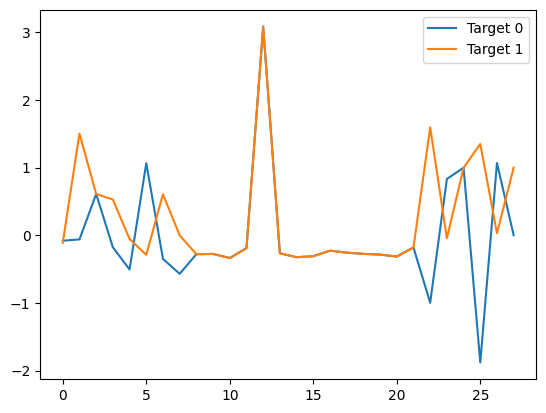

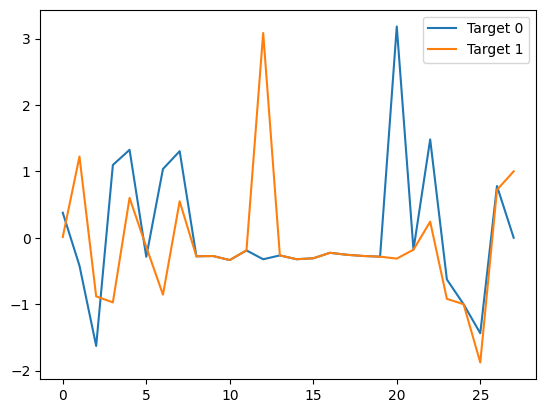

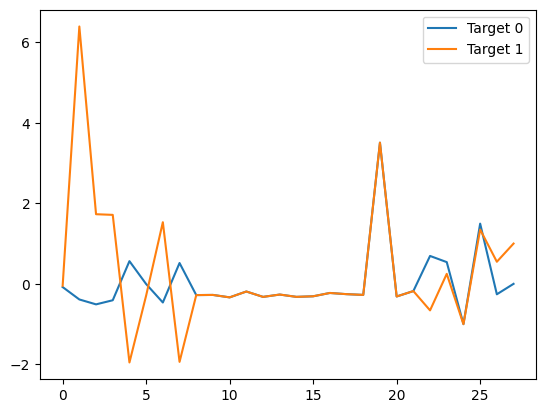

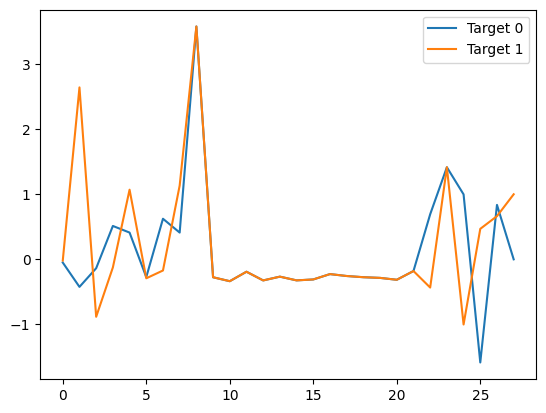

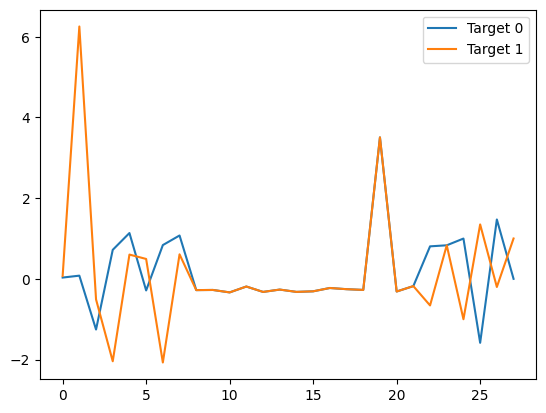

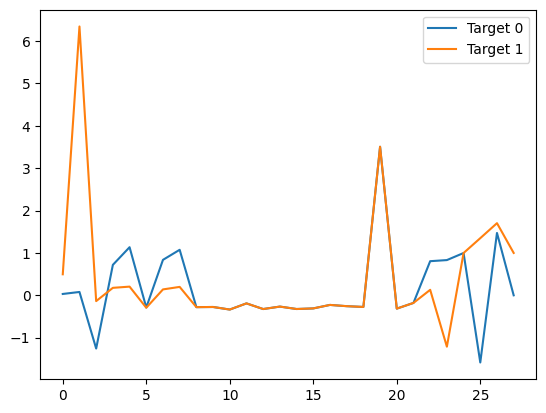

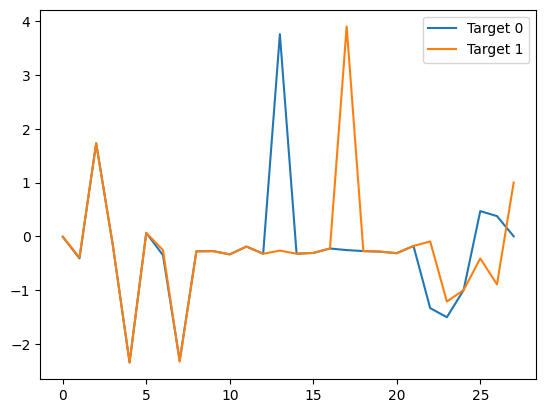

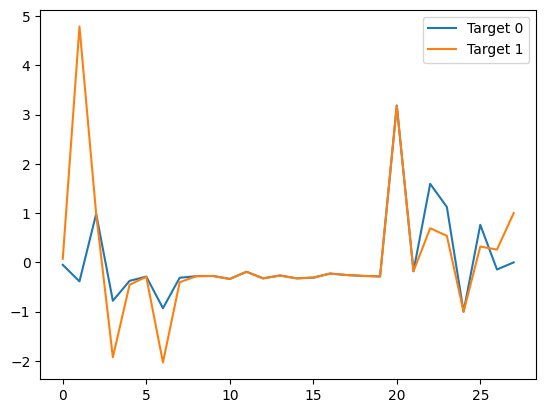

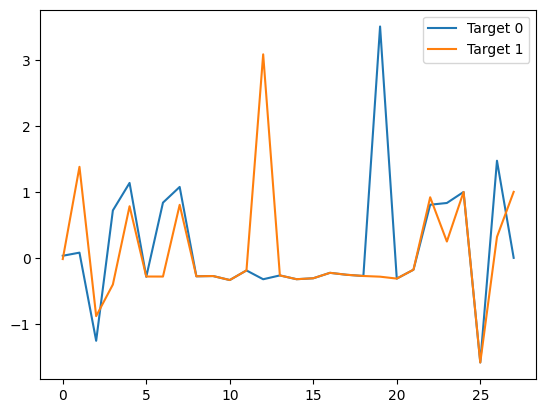

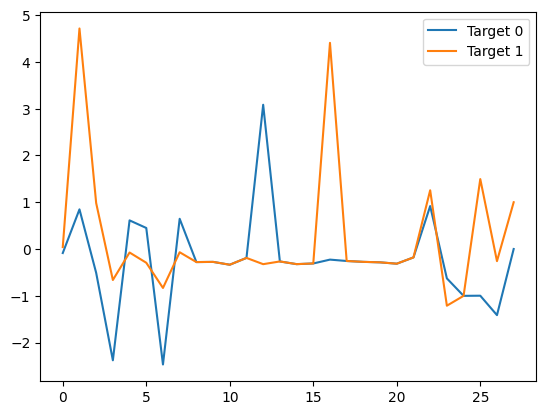

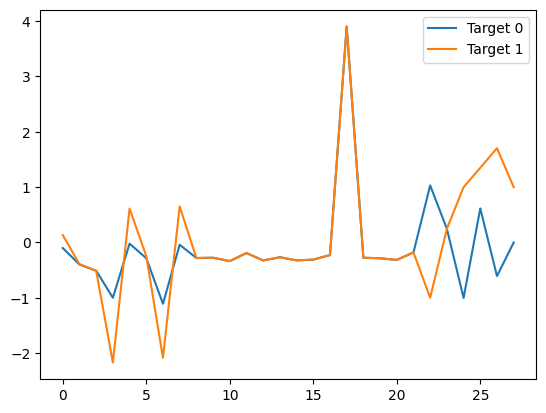

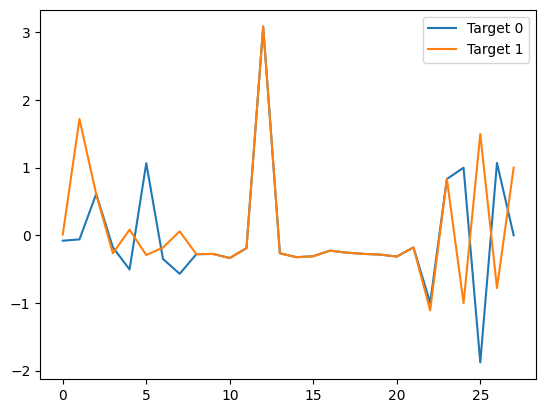

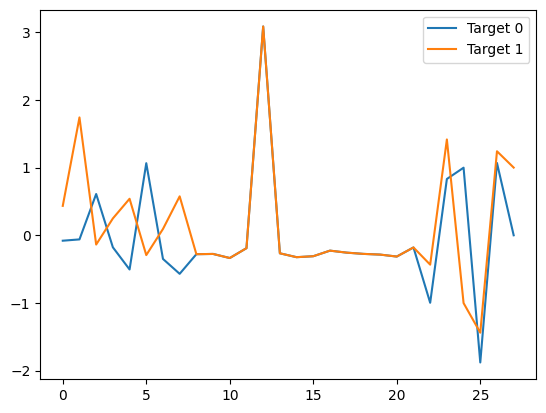

In [ ]:
# Korelasi lebih dari 0.2
for i in range (m):
  if sim[i] !=[]:
    plt.plot(sim[i][0])
    plt.plot(M_data_1[i])
    plt.legend(['Target 0', 'Target 1'])
    plt.show()

In [ ]:
len(sim[0])

13

In [ ]:
#Data yang berkorelasi kurang dari 0.2
for i in range (m):
  if M_data_0[i] not in sim[0]:
    plt.plot(M_data_0[i])
    plt.plot(M_data_1[i])
    plt.legend(['Target 0', 'Target 1'])
    plt.show()


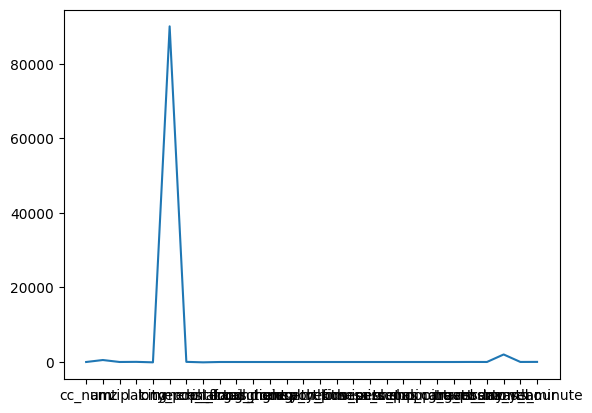

In [ ]:
plt.plot(data_0.columns,data_1.sum()/len(data_1))

In [ ]:
data_0.drop

,cc_num,amt,zip,lat,long,city_pop,merch_lat,merch_long,is_fraud,entertainment,...,misc_pos,personal_care,shopping_net,shopping_pos,travel,trans_day,trans_month,trans_year,trans_hour,trans_minute
0,0.006821,1.59,2,38.3880,-79.9906,365,38.122944,-80.347570,0,0,...,0,0,0,0,0,26,5,2019,1,47
1,0.003079,13.68,5,44.4477,-93.4252,5211,44.712822,-93.659916,0,0,...,0,0,0,0,0,31,3,2020,15,25
2,0.002737,2.88,6,37.3272,-91.0243,241,37.252571,-90.096817,0,0,...,0,0,0,0,1,6,7,2019,12,27
3,0.008158,49.43,4,36.8421,-85.5396,341,37.384484,-86.478409,0,0,...,0,1,0,0,0,19,9,2020,19,24
4,0.003763,77.38,3,31.6453,-90.1801,1196,32.208948,-90.146894,0,0,...,0,0,0,0,0,30,10,2019,21,23
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1852368,0.007478,79.43,4,39.5960,-86.1309,78968,39.193211,-86.117877,0,0,...,0,0,0,0,0,21,10,2019,13,0
1852369,0.002406,36.09,1,41.0001,-78.2357,3688,40.231109,-79.199929,0,1,...,0,0,0,0,0,7,6,2019,20,51
1852370,0.002734,8.72,7,32.9550,-92.5870,1758,32.374294,-92.431319,0,0,...,0,0,0,0,0,13,4,2019,11,55
1852371,0.005468,39.96,3,33.1410,-82.5150,741,32.243832,-83.105809,0,0,...,1,0,0,0,0,31,3,2020,8,30


## **Numerik Scalling**

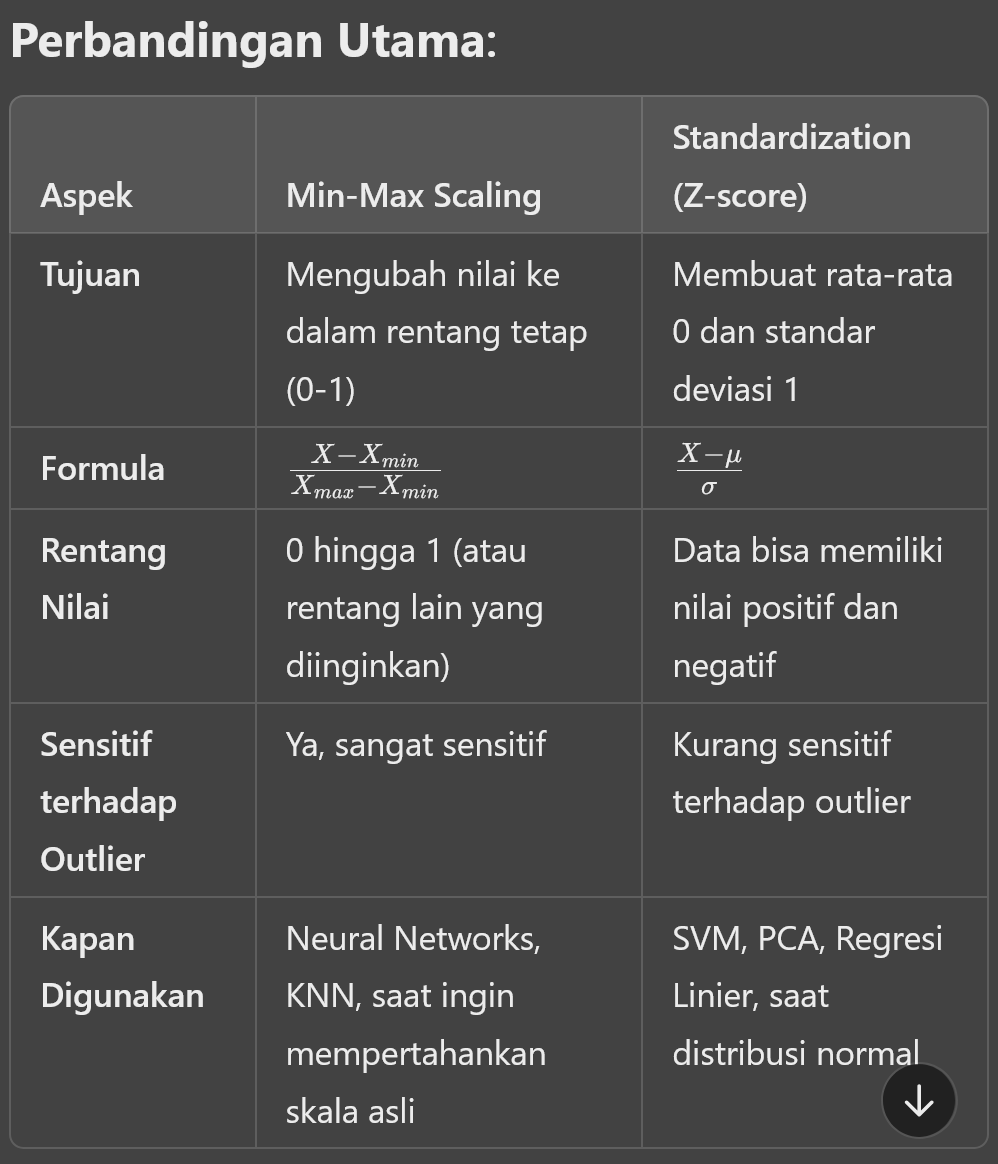

**Menggunakan min-max scalling**

In [ ]:
#data = (data-data.min())/(data.max()-data.min())

In [ ]:
data.head(3)

,cc_num,amt,zip,lat,long,city_pop,merch_lat,merch_long,is_fraud,entertainment,...,misc_pos,personal_care,shopping_net,shopping_pos,travel,trans_day,trans_month,trans_year,trans_hour,trans_minute
0,0.006821,85.64,6,42.4048,-88.3054,928,43.268344,-87.578803,0,1,...,0,0,0,0,0,20,4,2019,19,48
1,0.003199,7.74,2,39.1505,-79.5030,836,38.228366,-78.791572,0,0,...,0,0,0,0,0,29,8,2019,8,34
2,0.003083,7.89,0,42.7280,-71.1810,47249,43.394062,-72.116281,0,0,...,0,0,1,0,0,3,5,2019,18,23


# **Exploratory Data Analysis**

**Matriks Korelasi**

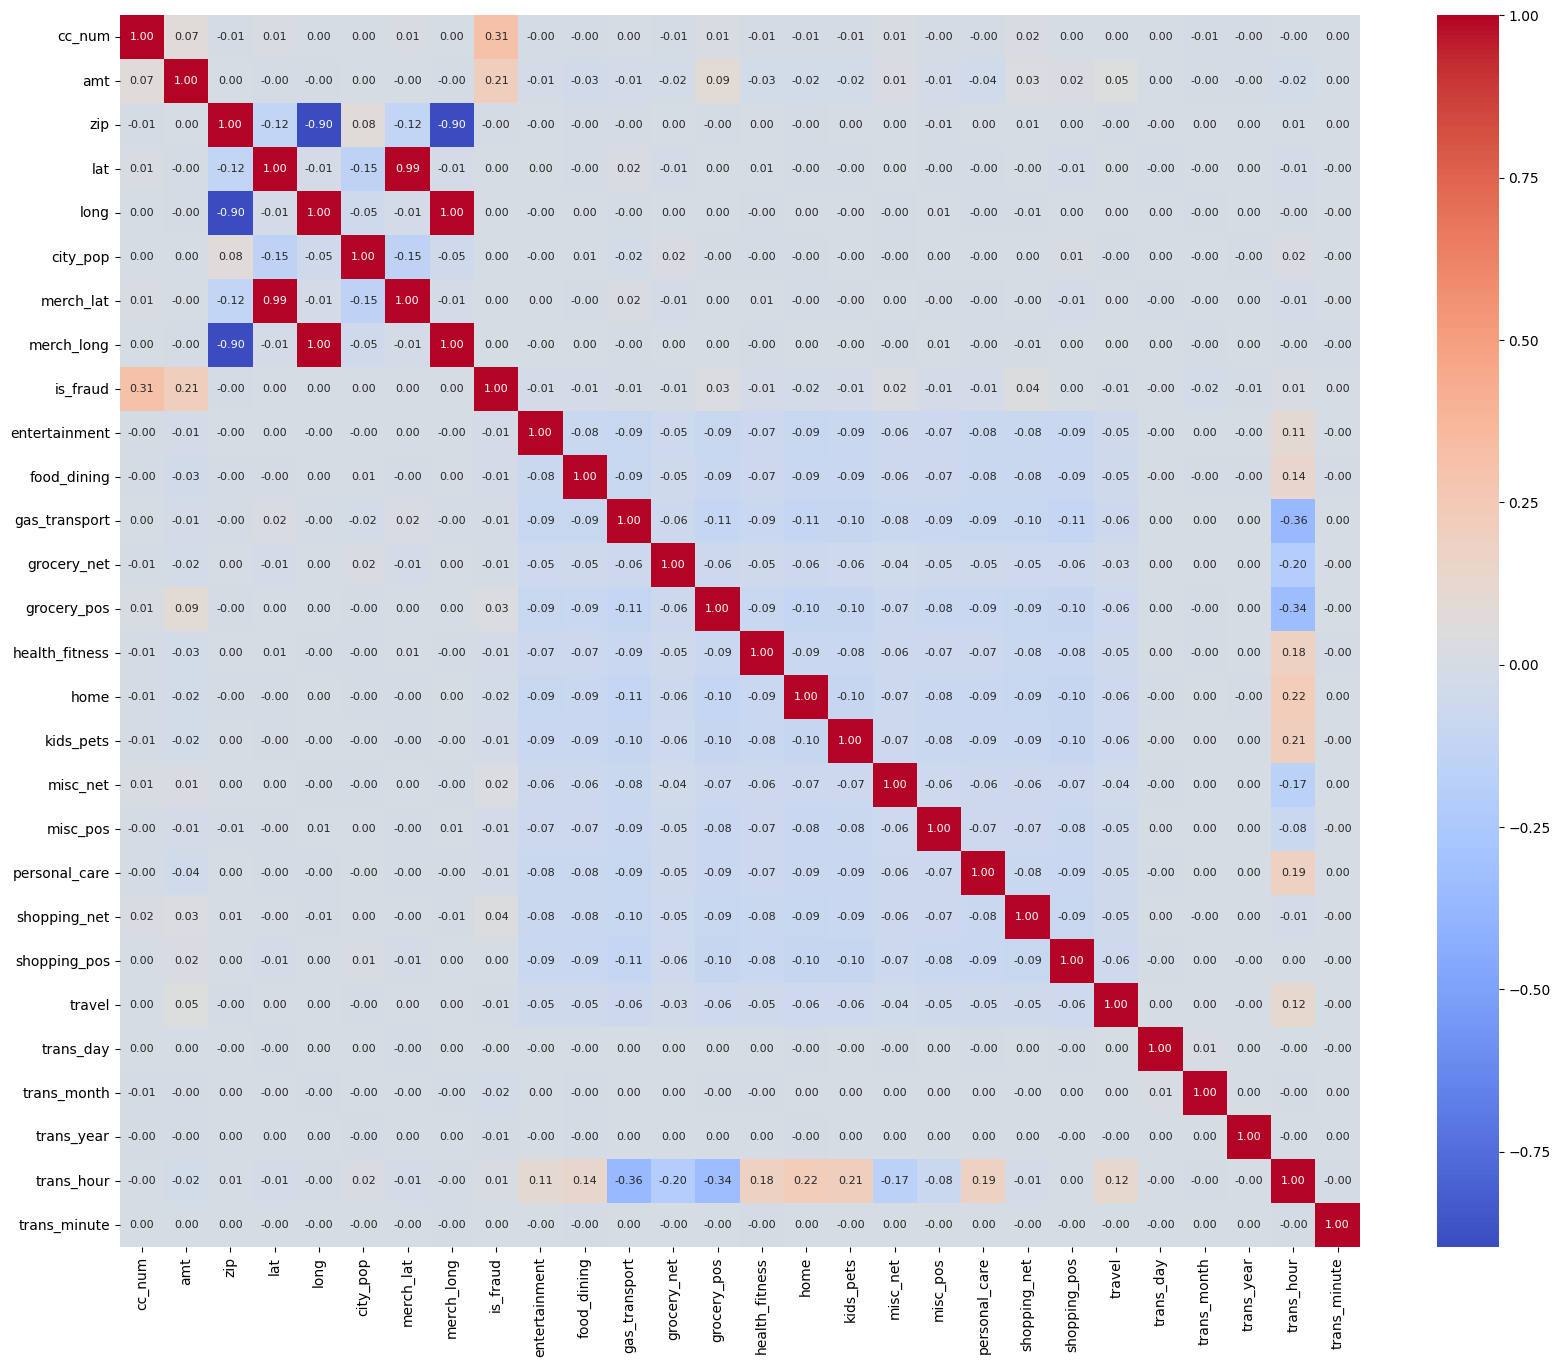

In [ ]:
plt.figure(figsize=(20, 16))
sns.heatmap(data.corr(), annot=True,annot_kws={"size": 8}, cmap="coolwarm",fmt='.2f')
plt.show()

Ada bebarapa fetaure variabel penjelas yang memiliki korelasi yang sangat tinggi antar dua feature tersebut secara numerik tetapi hal ini perlu validasi secara fisis. Apakah memang betul terdapat korelasi antara dua feature tersebut.
1. `merc_lattitude` vs `lat`: Nilai korelasi sebesar 0.99. Nilai ini cukup besar memang dan secara fisis juga dapat diterima bahwa keduanya memiliki korelasi yang sangat tinggi. Karena tempat bertransaksi yang dilakukan oleh pemegang kartu kredit letaknya tidak jauh dari tempat si pemegang kartu kredit.
2. `merch_long` vs `lon`: Nilai korelasi 1, hal ini sama seperti kasus sebelumnya.
3. `merch_long` vs `zip`: Nilai korelasi sebesar -0.90 . Data pada feature `zip` semakin ke barat nilainya semakin besar. Sedangkan nilai pada longitude semakin ke barat nilainya semakin kecil. Oleh karena itu feature ini memiliki korelasi negatif yang cukup tinggi (-0.9).
4. `long` vs `zip`: Sama seperti poin 3

Karena terdapat komponen penjelas yang berkorelasi sangat tinggi baik secara positif dan negatif maka diperlukan pengurangan (reduksi) pada feature. Pengurangan ukuran feature dilakukan menggunakan PCA.

In [ ]:
data.groupby('is_fraud').mean()['amt']

,amt
is_fraud,
0.0,0.002302
1.0,0.018219


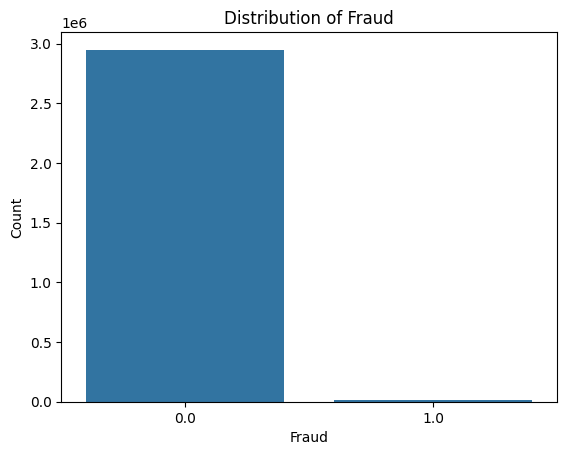

In [ ]:
fraud_counts=data['is_fraud'].value_counts()
sns.barplot(x=fraud_counts.index, y=fraud_counts.values)
plt.title('Distribution of Fraud')
plt.xlabel('Fraud')
plt.ylabel('Count')
plt.show()

# **Data For Modeling**

In [ ]:
X=data.drop('is_fraud',axis=1)
y=data['is_fraud']

membagi 20% menjadi data test dan 80% menjadi data train. Akan menggunakan tiga skenario untuk ukuran data yang digunakan dalam modeling.
1. Menggunakan data sesungguhnya 95%:5%
2. Menggunakan data under sampling 50%:50%
3. Menggunakan data under sampling 67%:33%

Untuk data yang under sampling, data yang tidak diikutkan dalam pemodelan akan digunakan untuk data testing.

In [ ]:
# @title Fungsi Transformasi Data untuk Keseluruhan Proses
def TransformPCA(X_data, vec_selected):
  X_mean = X_data.mean()
  X_std = X_data.std()
  X_norm = (X_data-X_mean)/X_std
  X_transform = X_norm.dot(vec_selected)
  X_transform.columns = [f'PCA Feature {i+1}' for i in range (len(X_transform.columns))]
  return (X_transform-X_transform.min())/(X_transform.max()-X_transform.min())

def CleanTransform(Data, vec_selected):
  #Drop Unused data
  Data = Data[['trans_date_trans_time', 'cc_num', 'category', 'amt', 'zip', 'lat',
       'long', 'city_pop', 'merch_lat', 'merch_long', 'is_fraud']]
  # Encoding Category
  Data_ = pd.get_dummies(Data['category']).astype(int)
  Data = pd.concat([Data,Data_], axis=1)
  Data = Data.drop(columns=['category'], axis=1)
  #Encoding cc_num
  Data['cc_num'] = Data['cc_num'].apply(TargetEncode)
  #Encoding Zip
  Data['zip']= Data['zip'].apply(ZipEncode)
  #Feature Engineering
  Data['trans_date_trans_time']=pd.to_datetime(Data['trans_date_trans_time'])
  Data['trans_day']=Data['trans_date_trans_time'].dt.day
  Data['trans_month']=Data['trans_date_trans_time'].dt.month
  Data['trans_year']=Data['trans_date_trans_time'].dt.year
  Data['trans_hour']=Data['trans_date_trans_time'].dt.hour
  Data['trans_minute']=Data['trans_date_trans_time'].dt.minute
  Data.drop(columns=['trans_date_trans_time'],inplace=True)
  #Split Data
  X = Data.drop(columns=['is_fraud'])
  y = Data['is_fraud'].values
  #Scalling
  X_transform= TransformPCA(X, vec_selected)
  return X_transform, y

## **Skenario 1: $95\%:5\%$**

Split data menjadi data training dan data testing

In [ ]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2,random_state=10)

### **PCA pada data training**

In [ ]:
# @title Main code PCA
mean = np.mean(X_train, axis=0)
std_ = np.std(X_train, axis=0)
df_std = (X_train-mean)/std_

mat_cov = np.cov(df_std, rowvar=False)
eigenvalues, vectoreigen = np.linalg.eig(mat_cov)
index = np.argsort(eigenvalues)[::-1]
eigenvalues_sorted = eigenvalues[index]
vectoreigen_sorted = vectoreigen[:,index]
Total = sum(eigenvalues_sorted)
var_exp = [i*100/Total for i in eigenvalues_sorted]
cum_var_exp = np.cumsum(var_exp)

In [ ]:
# @title Plot PCA results
with plt.style.context('seaborn-whitegrid'):
    plt.figure(figsize=(10, 6))

    plt.bar(range(len(X.columns)), var_exp, alpha=0.5, align='center',
            label='individual explained variance')
    plt.step(range(len(X.columns)), cum_var_exp, where='mid',
             label='cumulative explained variance')
    for i, core_val in enumerate(cum_var_exp):
      plt.annotate(str(round(cum_var_exp[i],1))+'%', (i-0.8, cum_var_exp[i]), xytext=(3, 6), textcoords='offset points',fontsize = 8)
    plt.ylabel('Explained variance ratio')
    plt.xlabel('Principal components')
    plt.legend(loc='best')
    plt.tight_layout()

In [ ]:
# @title Hasil PCA
print(f'Komponen sebelumnya: {len(cum_var_exp)}')
for i,cum_ in enumerate(cum_var_exp):
  if cum_>95:
    print (f'Komponen yang digunakan: {i+1}')
    n_component=i+1
    print(f'Signifikansi Komponen: {cum_}')
    break

Komponen sebelumnya: 27
Komponen yang digunakan: 21
Signifikansi Komponen: 95.08241777954981


Akan menggunakan 21 komponen sehingga komponen yang digunakan sudah melingkupi 95.08%

In [ ]:
# @title Default title text
vector_selected1 = vectoreigen_sorted[:,:n_component]
result = df_std.dot(vector_selected1)
result.columns = [f'PCA Feature {i+1}' for i in range (n_component)]

In [ ]:
result.head(3)

,PCA Feature 1,PCA Feature 2,PCA Feature 3,PCA Feature 4,PCA Feature 5,PCA Feature 6,PCA Feature 7,PCA Feature 8,PCA Feature 9,PCA Feature 10,...,PCA Feature 12,PCA Feature 13,PCA Feature 14,PCA Feature 15,PCA Feature 16,PCA Feature 17,PCA Feature 18,PCA Feature 19,PCA Feature 20,PCA Feature 21
1262795,1.821832,3.886172,2.481060,2.196237,-0.165506,-0.602332,-1.623916,-0.540286,0.383993,-0.003827,...,0.055377,0.408065,-1.096125,-0.532245,0.698945,-1.601540,-1.012966,0.322639,0.719512,8.528041
1580890,-0.921711,-0.365640,-0.476784,-0.387737,0.286676,-0.225128,-1.141571,0.767446,1.356541,-0.143699,...,1.212882,-0.187703,0.150683,0.185781,0.131187,0.281834,0.939155,-0.793286,-0.504912,-0.238930
720826,3.673143,1.720099,0.530225,1.506239,0.445741,0.145767,1.834601,2.215481,1.302110,0.379158,...,0.031318,0.617394,-1.237888,-0.068208,0.932872,0.292931,-0.521174,-0.928307,1.116214,3.284309


In [ ]:
result.agg(['min','max'])

,PCA Feature 1,PCA Feature 2,PCA Feature 3,PCA Feature 4,PCA Feature 5,PCA Feature 6,PCA Feature 7,PCA Feature 8,PCA Feature 9,PCA Feature 10,...,PCA Feature 12,PCA Feature 13,PCA Feature 14,PCA Feature 15,PCA Feature 16,PCA Feature 17,PCA Feature 18,PCA Feature 19,PCA Feature 20,PCA Feature 21
min,-3.038652,-9.363683,-2.377567,-1.913434,-2.883782,-2.152329,-1.754005,-2.049729,-16.064992,-6.465274,...,-3.545881,-22.925640,-1.607555,-15.274536,-13.559660,-28.511840,-8.273199,-19.343421,-15.893320,-7.065484
max,7.009940,4.380831,14.901949,104.561940,2.470125,3.324733,21.779688,6.831741,2.238008,2.896752,...,2.745590,2.666441,21.100135,3.959048,2.760517,3.300245,2.364351,2.324851,3.130982,8.809323


Karena hasil dari PCA masih belum terletak pada rentang $[0,1]$ dan memungkinkan data tidak dikenali oleh algoritma, akan dilakukan scalling $min-max$

In [ ]:
# Data Train
X_train1 = (result-result.min())/(result.max()-result.min())
y_train1 = y_train.copy()
X_train1.head(3)

,PCA Feature 1,PCA Feature 2,PCA Feature 3,PCA Feature 4,PCA Feature 5,PCA Feature 6,PCA Feature 7,PCA Feature 8,PCA Feature 9,PCA Feature 10,...,PCA Feature 12,PCA Feature 13,PCA Feature 14,PCA Feature 15,PCA Feature 16,PCA Feature 17,PCA Feature 18,PCA Feature 19,PCA Feature 20,PCA Feature 21
1262795,0.483698,0.964010,0.281178,0.038597,0.507718,0.282998,0.005528,0.169954,0.898704,0.690176,...,0.572403,0.911755,0.022522,0.766487,0.873680,0.845914,0.682510,0.907597,0.873243,0.982281
1580890,0.210670,0.654664,0.110002,0.014329,0.592177,0.351868,0.026024,0.317197,0.951840,0.675236,...,0.756383,0.888476,0.077429,0.803819,0.838891,0.905117,0.866022,0.856097,0.808882,0.430024
720826,0.667934,0.806415,0.168280,0.032117,0.621886,0.419586,0.152488,0.480237,0.948866,0.731085,...,0.568579,0.919934,0.016279,0.790613,0.888013,0.905466,0.728742,0.849865,0.894095,0.651963


In [ ]:
#Data Test
X_test1 = TransformPCA(X_test, vector_selected1)
y_test1 = y_test.copy()
X_test1.head(3)

,PCA Feature 1,PCA Feature 2,PCA Feature 3,PCA Feature 4,PCA Feature 5,PCA Feature 6,PCA Feature 7,PCA Feature 8,PCA Feature 9,PCA Feature 10,...,PCA Feature 12,PCA Feature 13,PCA Feature 14,PCA Feature 15,PCA Feature 16,PCA Feature 17,PCA Feature 18,PCA Feature 19,PCA Feature 20,PCA Feature 21
904389,0.459826,0.910523,0.257646,0.008452,0.567713,0.384964,0.042817,0.234275,0.928168,0.773253,...,0.533938,0.975785,0.033796,0.596386,0.860861,0.843969,0.574070,0.893622,0.793477,0.323811
1643584,0.015544,0.539396,0.253199,0.004777,0.512924,0.410335,0.142796,0.239839,0.812127,0.593736,...,0.596265,0.864439,0.081968,0.798965,0.711497,0.873922,0.797702,0.916197,0.811312,0.464942
986647,0.349937,0.612815,0.059391,0.019924,0.736342,0.029705,0.132506,0.014334,0.893185,0.714541,...,0.604354,0.899978,0.074372,0.801580,0.781727,0.911471,0.903537,0.858484,0.786371,0.429880


In [ ]:
'''
Data_test1=  pd.concat([X_test1,y_test1], axis=1)
Data_train1 = pd.concat([X_train1,y_train1], axis=1)
from google.colab import files
#Data_train1.to_excel('Data_train.xlsx', index=False)
Data_test1.to_csv('Data_test.csv', index = False)

#files.download('Data_train.xlsx')
files.download('Data_test.csv')
'''

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

## **Skenario 2: Undersampling $50\%:50\%$**

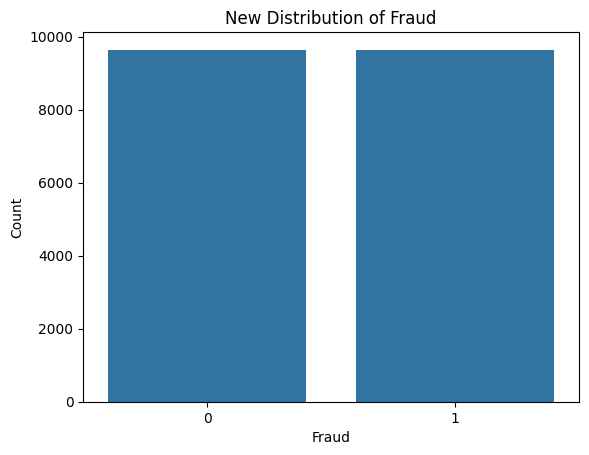

In [ ]:
fraud=data[data["is_fraud"].astype('int')==1]
not_fraud=data[data["is_fraud"].astype('int')==0]
not_fraud_=not_fraud.sample(fraud.shape[0], random_state=99)
Data=pd.concat([fraud,not_fraud_]).sample(frac=1, random_state=42).reset_index(drop=True).sort_index()
Data_test = not_fraud.drop(index=not_fraud_.index)

fraud_counts=Data['is_fraud'].value_counts()
sns.barplot(x=fraud_counts.index,y=fraud_counts.values)
plt.title('New Distribution of Fraud')
plt.xlabel('Fraud')
plt.ylabel('Count')
plt.show()

In [ ]:
Data.groupby('is_fraud')['is_fraud'].count()

,is_fraud
is_fraud,
0,9641
1,9641


In [ ]:
Data_test['is_fraud'].value_counts()

,count
is_fraud,
0,1833092


In [ ]:
X = Data.drop(columns='is_fraud')
y= Data['is_fraud']

In [ ]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2,random_state=10)

### **PCA pada data training**

In [ ]:
# @title Main code PCA
mean = np.mean(X_train, axis=0)
std_ = np.std(X_train, axis=0)
df_std = (X_train-mean)/std_

mat_cov = np.cov(df_std, rowvar=False)
eigenvalues, vectoreigen = np.linalg.eig(mat_cov)
index = np.argsort(eigenvalues)[::-1]
eigenvalues_sorted = eigenvalues[index]
vectoreigen_sorted = vectoreigen[:,index]
Total = sum(eigenvalues_sorted)
var_exp = [i*100/Total for i in eigenvalues_sorted]
cum_var_exp = np.cumsum(var_exp)

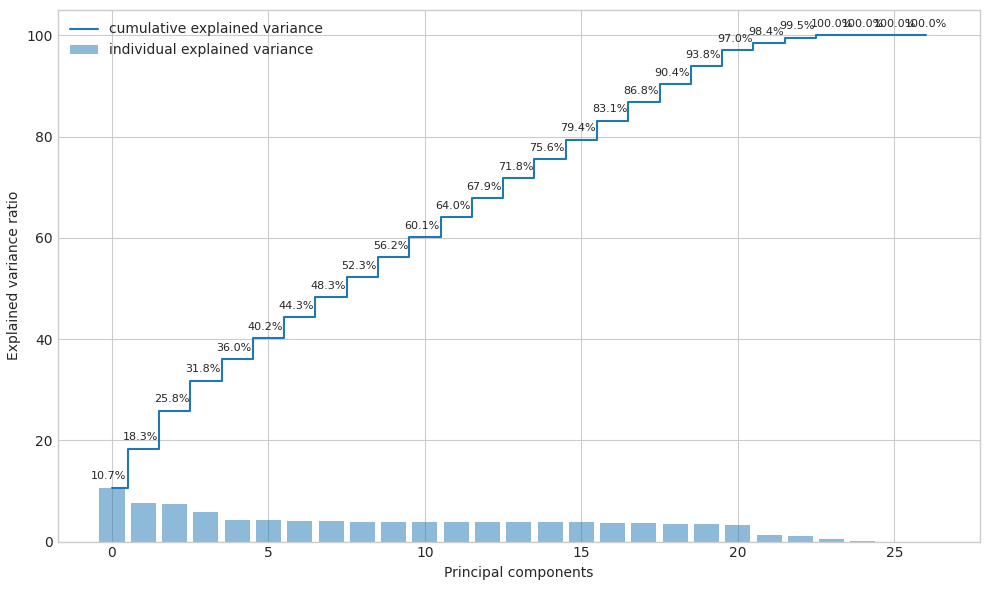

In [ ]:
# @title Plot PCA results
with plt.style.context('seaborn-whitegrid'):
    plt.figure(figsize=(10, 6))

    plt.bar(range(len(X.columns)), var_exp, alpha=0.5, align='center',
            label='individual explained variance')
    plt.step(range(len(X.columns)), cum_var_exp, where='mid',
             label='cumulative explained variance')
    for i, core_val in enumerate(cum_var_exp):
      plt.annotate(str(round(cum_var_exp[i],1))+'%', (i-0.8, cum_var_exp[i]), xytext=(3, 6), textcoords='offset points',fontsize = 8)
    plt.ylabel('Explained variance ratio')
    plt.xlabel('Principal components')
    plt.legend(loc='best')
    plt.tight_layout()

In [ ]:
# @title Hasil PCA
print(f'Komponen sebelumnya: {len(cum_var_exp)}')
for i,cum_ in enumerate(cum_var_exp):
  if cum_>95:
    print (f'Komponen yang digunakan: {i+1}')
    n_component=i+1
    print(f'Signifikansi Komponen: {cum_}')
    break

Komponen sebelumnya: 27
Komponen yang digunakan: 21
Signifikansi Komponen: 97.03267480688586


Akan menggunakan 21 komponen sehingga komponen yang digunakan sudah melingkupi 95.08%

In [ ]:
# @title Vector selected dan resultt
vector_selected2 = vectoreigen_sorted[:,:n_component]
result = df_std.dot(vector_selected2)
result.columns = [f'PCA Feature {i+1}' for i in range (n_component)]

In [ ]:
result.head(3)

,PCA Feature 1,PCA Feature 2,PCA Feature 3,PCA Feature 4,PCA Feature 5,PCA Feature 6,PCA Feature 7,PCA Feature 8,PCA Feature 9,PCA Feature 10,...,PCA Feature 12,PCA Feature 13,PCA Feature 14,PCA Feature 15,PCA Feature 16,PCA Feature 17,PCA Feature 18,PCA Feature 19,PCA Feature 20,PCA Feature 21
6523,0.339027,1.811545,1.131872,-0.137021,0.525470,-2.468903,-1.584082,0.985443,0.264427,0.248464,...,0.307927,-0.310983,-0.157585,-0.751591,0.638913,-1.056578,0.067947,-0.460895,-0.236451,0.078869
7779,-1.544010,0.888056,0.368223,-0.501865,-0.139275,0.453737,0.814874,1.175517,-0.053119,1.389147,...,1.110702,0.171671,3.855849,-0.667657,-0.032165,0.104530,2.608147,-3.193625,-0.347353,-3.515656
590,2.054287,0.725794,0.078813,-0.509362,0.269882,-2.504117,-1.689053,0.835551,-0.279369,0.259377,...,-0.041278,-0.141635,0.287524,0.102792,0.225082,0.243047,-1.199949,-0.604197,1.057871,-0.149106


In [ ]:
result.agg(['min','max'])

,PCA Feature 1,PCA Feature 2,PCA Feature 3,PCA Feature 4,PCA Feature 5,PCA Feature 6,PCA Feature 7,PCA Feature 8,PCA Feature 9,PCA Feature 10,...,PCA Feature 12,PCA Feature 13,PCA Feature 14,PCA Feature 15,PCA Feature 16,PCA Feature 17,PCA Feature 18,PCA Feature 19,PCA Feature 20,PCA Feature 21
min,-2.852183,-5.014188,-4.429052,-2.285485,-2.540265,-2.854974,-2.332502,-3.310786,-3.043425,-3.013332,...,-2.760210,-3.757825,-2.807991,-2.253437,-2.515013,-5.281004,-2.531214,-6.059278,-3.797006,-4.283550
max,7.579402,10.087952,17.888665,11.232877,2.931958,2.292036,4.798501,4.630898,3.802183,3.441863,...,3.852613,3.901106,4.954863,6.691731,6.544793,6.440541,3.843856,2.894657,2.829539,5.992001


Karena hasil dari PCA masih belum terletak pada rentang $[0,1]$ dan memungkinkan data tidak dikenali oleh algoritma, akan dilakukan scalling $min-max$

In [ ]:
# Data Train
X_train2 = (result-result.min())/(result.max()-result.min())
y_train2 = y_train.copy()
X_train2.head(3)

,PCA Feature 1,PCA Feature 2,PCA Feature 3,PCA Feature 4,PCA Feature 5,PCA Feature 6,PCA Feature 7,PCA Feature 8,PCA Feature 9,PCA Feature 10,...,PCA Feature 12,PCA Feature 13,PCA Feature 14,PCA Feature 15,PCA Feature 16,PCA Feature 17,PCA Feature 18,PCA Feature 19,PCA Feature 20,PCA Feature 21
6523,0.305918,0.451971,0.249171,0.158929,0.560236,0.075009,0.104953,0.540972,0.483208,0.505298,...,0.463968,0.450042,0.341422,0.167895,0.348123,0.360398,0.407707,0.625243,0.537317,0.424544
7779,0.125405,0.390822,0.214954,0.131941,0.438760,0.642841,0.441365,0.564906,0.436821,0.682006,...,0.585364,0.513061,0.858427,0.177278,0.274051,0.459456,0.806165,0.320044,0.520581,0.074730
590,0.470348,0.380077,0.201986,0.131386,0.513529,0.068167,0.090233,0.522098,0.403771,0.506988,...,0.411161,0.472153,0.398760,0.263408,0.302445,0.471273,0.208824,0.609238,0.732641,0.402357


In [ ]:
#Data Test
X_test2 = TransformPCA(X_test, vector_selected2)
y_test2 = y_test.copy()
X_test2.head(3)

,PCA Feature 1,PCA Feature 2,PCA Feature 3,PCA Feature 4,PCA Feature 5,PCA Feature 6,PCA Feature 7,PCA Feature 8,PCA Feature 9,PCA Feature 10,...,PCA Feature 12,PCA Feature 13,PCA Feature 14,PCA Feature 15,PCA Feature 16,PCA Feature 17,PCA Feature 18,PCA Feature 19,PCA Feature 20,PCA Feature 21
1427,0.109032,0.435153,0.259434,0.347918,0.426134,0.546977,0.333771,0.291237,0.292406,0.633243,...,0.368246,0.690401,0.391991,0.178028,0.388074,0.513908,0.286121,0.735022,0.884032,0.352668
13864,0.304866,0.656408,0.755754,0.699932,0.457500,0.855234,0.324309,0.425965,0.372149,0.514914,...,0.394283,0.500481,0.423736,0.378702,0.275081,0.581689,0.476364,0.437325,0.454513,0.087631
15493,0.168436,0.446252,0.746410,0.635324,0.503385,0.079646,0.188094,0.667263,0.463309,0.442114,...,0.376958,0.536453,0.368695,0.300624,0.319563,0.519619,0.865599,0.414326,0.618923,0.085637


In [ ]:
# Data test tambahah
X = Data_test.drop(columns='is_fraud')
y_test2_1 = Data_test['is_fraud']
X_test2_1 = TransformPCA(X,vector_selected2 )

In [ ]:
Data_test2=  pd.concat([X_test2,y_test2], axis=1)
Data_train2 = pd.concat([X_train2,y_train2], axis=1)
from google.colab import files
Data_train2.to_excel('Data_train.xlsx', index=False)
Data_test2.to_csv('Data_test2.csv', index = False)

files.download('Data_train.xlsx')
files.download('Data_test2.csv')

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

## **Skenario 3: Undersampling $67\%:33\%$**

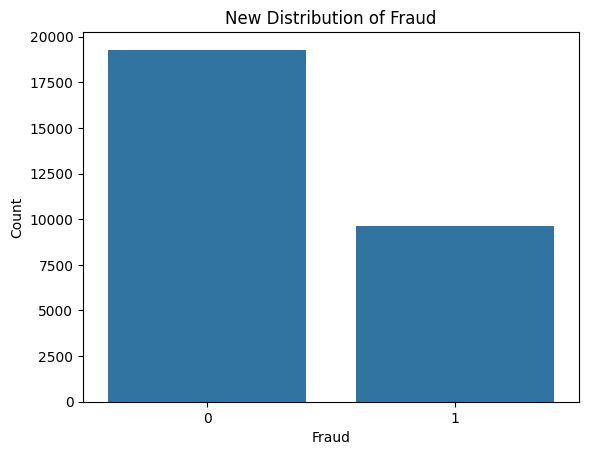

In [ ]:
fraud=data[data["is_fraud"].astype('int')==1]
not_fraud=data[data["is_fraud"].astype('int')==0]
not_fraud_=not_fraud.sample(len(fraud)*2, random_state=98)
Data=pd.concat([fraud,not_fraud_]).sample(frac=1, random_state=41).reset_index(drop=True).sort_index()
Data_test = not_fraud.drop(index=not_fraud_.index)

fraud_counts=Data['is_fraud'].value_counts()
sns.barplot(x=fraud_counts.index,y=fraud_counts.values)
plt.title('New Distribution of Fraud')
plt.xlabel('Fraud')
plt.ylabel('Count')
plt.show()

In [ ]:
Data.groupby('is_fraud')['is_fraud'].count()

,is_fraud
is_fraud,
0,19282
1,9641


In [ ]:
Data_test['is_fraud'].value_counts()

,count
is_fraud,
0,1823451


In [ ]:
X = Data.drop(columns='is_fraud')
y= Data['is_fraud'].values

In [ ]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2,random_state=10)

### **PCA pada data training**

In [ ]:
# @title Main code PCA
mean = np.mean(X_train, axis=0)
std_ = np.std(X_train, axis=0)
df_std = (X_train-mean)/std_

mat_cov = np.cov(df_std, rowvar=False)
eigenvalues, vectoreigen = np.linalg.eig(mat_cov)
index = np.argsort(eigenvalues)[::-1]
eigenvalues_sorted = eigenvalues[index]
vectoreigen_sorted = vectoreigen[:,index]
Total = sum(eigenvalues_sorted)
var_exp = [i*100/Total for i in eigenvalues_sorted]
cum_var_exp = np.cumsum(var_exp)

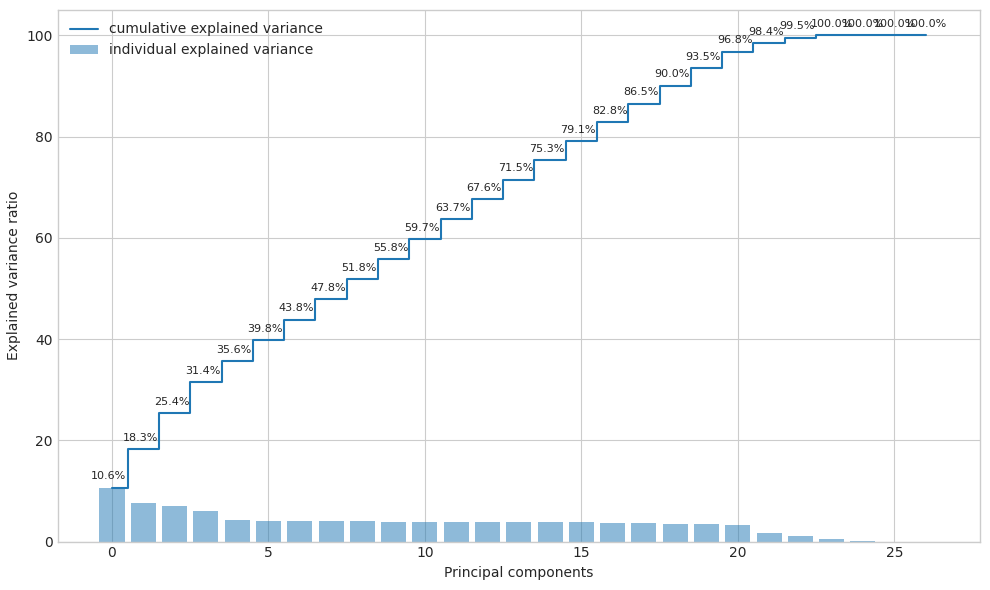

In [ ]:
# @title Plot PCA results
with plt.style.context('seaborn-whitegrid'):
    plt.figure(figsize=(10, 6))

    plt.bar(range(len(X.columns)), var_exp, alpha=0.5, align='center',
            label='individual explained variance')
    plt.step(range(len(X.columns)), cum_var_exp, where='mid',
             label='cumulative explained variance')
    for i, core_val in enumerate(cum_var_exp):
      plt.annotate(str(round(cum_var_exp[i],1))+'%', (i-0.8, cum_var_exp[i]), xytext=(3, 6), textcoords='offset points',fontsize = 8)
    plt.ylabel('Explained variance ratio')
    plt.xlabel('Principal components')
    plt.legend(loc='best')
    plt.tight_layout()

In [ ]:
# @title Hasil PCA
print(f'Komponen sebelumnya: {len(cum_var_exp)}')
for i,cum_ in enumerate(cum_var_exp):
  if cum_>95:
    print (f'Komponen yang digunakan: {i+1}')
    n_component=i+1
    print(f'Signifikansi Komponen: {cum_}')
    break

Komponen sebelumnya: 27
Komponen yang digunakan: 21
Signifikansi Komponen: 96.78262319906031


Akan menggunakan 21 komponen sehingga komponen yang digunakan sudah melingkupi 95.08%

In [ ]:
# @title Vector selected dan resultt
vector_selected3 = vectoreigen_sorted[:,:n_component]
result = df_std.dot(vector_selected3)
result.columns = [f'PCA Feature {i+1}' for i in range (n_component)]

In [ ]:
result.head(3)

,PCA Feature 1,PCA Feature 2,PCA Feature 3,PCA Feature 4,PCA Feature 5,PCA Feature 6,PCA Feature 7,PCA Feature 8,PCA Feature 9,PCA Feature 10,...,PCA Feature 12,PCA Feature 13,PCA Feature 14,PCA Feature 15,PCA Feature 16,PCA Feature 17,PCA Feature 18,PCA Feature 19,PCA Feature 20,PCA Feature 21
3239,0.882673,2.977197,-0.352838,-1.271870,-0.312259,-0.250736,-0.316527,0.443829,-1.079283,2.692283,...,-2.425402,-1.195203,-0.445243,-0.206319,0.385138,0.226584,1.611427,-1.069656,-1.522628,0.384636
11165,-1.247198,0.096578,-0.062171,-1.814135,-0.167210,-0.201483,-0.019709,0.654867,-0.156532,1.954214,...,3.259602,-0.309798,-1.042540,-0.742111,0.446129,-0.788631,-1.505995,-0.708205,0.406196,-0.663978
21421,1.574900,0.270390,-0.698314,-0.671333,0.185691,2.831426,1.036593,1.085342,-0.071513,0.281433,...,0.151965,-0.096882,0.085304,-0.044640,-0.346139,-0.407038,0.767897,-0.794332,-0.943081,0.004846


In [ ]:
result.agg(['min','max'])

,PCA Feature 1,PCA Feature 2,PCA Feature 3,PCA Feature 4,PCA Feature 5,PCA Feature 6,PCA Feature 7,PCA Feature 8,PCA Feature 9,PCA Feature 10,...,PCA Feature 12,PCA Feature 13,PCA Feature 14,PCA Feature 15,PCA Feature 16,PCA Feature 17,PCA Feature 18,PCA Feature 19,PCA Feature 20,PCA Feature 21
min,-7.346182,-8.708571,-14.168992,-2.330896,-2.368609,-1.774833,-4.808674,-3.246267,-1.885365,-2.978311,...,-3.257794,-1.930660,-5.462370,-1.288807,-4.418386,-3.340177,-3.181787,-3.513108,-2.748501,-5.463744
max,2.919558,4.958078,2.999211,7.834110,2.445796,3.641774,1.630131,3.123556,3.819506,3.096902,...,3.734524,4.882742,2.830851,7.736289,5.393098,3.650257,5.855723,3.194551,7.746599,5.741093


Karena hasil dari PCA masih belum terletak pada rentang $[0,1]$ dan memungkinkan data tidak dikenali oleh algoritma, akan dilakukan scalling $min-max$

In [ ]:
# Data Train
X_train3 = (result-result.min())/(result.max()-result.min())
y_train3 = y_train.copy()
X_train3.head(3)

,PCA Feature 1,PCA Feature 2,PCA Feature 3,PCA Feature 4,PCA Feature 5,PCA Feature 6,PCA Feature 7,PCA Feature 8,PCA Feature 9,PCA Feature 10,...,PCA Feature 12,PCA Feature 13,PCA Feature 14,PCA Feature 15,PCA Feature 16,PCA Feature 17,PCA Feature 18,PCA Feature 19,PCA Feature 20,PCA Feature 21
3239,0.801584,0.855057,0.804753,0.104183,0.427124,0.281375,0.697668,0.579309,0.141297,0.933398,...,0.119044,0.107943,0.604967,0.119942,0.489582,0.510235,0.530369,0.364278,0.116804,0.521951
11165,0.594111,0.644280,0.821683,0.050837,0.457253,0.290468,0.743766,0.612440,0.303045,0.811910,...,0.932079,0.237893,0.532945,0.060575,0.495798,0.365005,0.185426,0.418164,0.300588,0.428366
21421,0.869015,0.656998,0.784629,0.163262,0.530554,0.850396,0.907819,0.680020,0.317948,0.536565,...,0.487643,0.269143,0.668941,0.137856,0.415049,0.419593,0.437032,0.405324,0.172025,0.488056


In [ ]:
#Data Test
X_test3 = TransformPCA(X_test, vector_selected2)
y_test3 = y_test.copy()
X_test3.head(3)

,PCA Feature 1,PCA Feature 2,PCA Feature 3,PCA Feature 4,PCA Feature 5,PCA Feature 6,PCA Feature 7,PCA Feature 8,PCA Feature 9,PCA Feature 10,...,PCA Feature 12,PCA Feature 13,PCA Feature 14,PCA Feature 15,PCA Feature 16,PCA Feature 17,PCA Feature 18,PCA Feature 19,PCA Feature 20,PCA Feature 21
6756,0.061541,0.533894,0.619549,0.450678,0.552279,0.828512,0.267900,0.428271,0.434996,0.547228,...,0.466850,0.436928,0.404046,0.211747,0.393324,0.403636,0.063296,0.714976,0.661225,0.461406
14261,0.356132,0.311701,0.303230,0.567051,0.228595,0.607916,0.267055,0.377441,0.543289,0.466201,...,0.478465,0.371650,0.308278,0.145698,0.283981,0.210367,0.541614,0.543453,0.615785,0.431186
7950,0.577321,0.311498,0.459631,0.094493,0.418451,0.609718,0.316998,0.318923,0.412138,0.631551,...,0.626810,0.486504,0.870356,0.232011,0.144574,0.476779,0.547344,0.716328,0.534136,0.395024


In [ ]:
len(y_train3)

23138

In [ ]:
# Data test tambahah
X = Data_test.drop(columns='is_fraud')
y_test3_1 = Data_test['is_fraud']
X_test3_1 = TransformPCA(X,vector_selected2 )

In [ ]:
'''
Data_test1=  pd.concat([X_test1,y_test1], axis=1)
Data_train1 = pd.concat([X_train1,y_train1], axis=1)
from google.colab import files
#Data_train1.to_excel('Data_train.xlsx', index=False)
Data_test1.to_csv('Data_test.csv', index = False)

#files.download('Data_train.xlsx')
files.download('Data_test.csv')
'''

# **Modeling ANN**

## **Modeling Skenario 1**

In [ ]:
# @title Default title text
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense
from sklearn.preprocessing import StandardScaler

In [ ]:
# @title Default title text
model = Sequential()

# Input layer and first hidden layer with 10 neurons
model.add(Dense(units=10, activation='relu', input_shape=(result.shape[1],)))

# Add second hidden layer with 8 neurons
model.add(Dense(units=8, activation='relu'))

# Add third hidden layer with 6 neurons
model.add(Dense(units=6, activation='relu'))

# Output layer (for binary classification)
model.add(Dense(units=1, activation='sigmoid'))

/usr/local/lib/python3.10/dist-packages/keras/src/layers/core/dense.py:87: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Transformasi data yang bersih

In [ ]:
# @title Default title text
model.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])

**Model Training**

In [ ]:
history = model.fit(result, y_train, epochs=50, batch_size=32, validation_data=(x_test, y_test))

Epoch 1/50
752/752 ━━━━━━━━━━━━━━━━━━━━ 6s 6ms/step - accuracy: 0.6271 - loss: 0.6525 - val_accuracy: 0.7488 - val_loss: 0.5067
Epoch 2/50
752/752 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - accuracy: 0.7594 - loss: 0.4861 - val_accuracy: 0.8306 - val_loss: 0.3946
Epoch 3/50
752/752 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - accuracy: 0.8295 - loss: 0.3964 - val_accuracy: 0.8377 - val_loss: 0.3689
Epoch 4/50
752/752 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - accuracy: 0.8394 - loss: 0.3746 - val_accuracy: 0.8462 - val_loss: 0.3564
Epoch 5/50
752/752 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step - accuracy: 0.8500 - loss: 0.3577 - val_accuracy: 0.8504 - val_loss: 0.3461
Epoch 6/50
752/752 ━━━━━━━━━━━━━━━━━━━━ 3s 2ms/step - accuracy: 0.8558 - loss: 0.3428 - val_accuracy: 0.8555 - val_loss: 0.3342
Epoch 7/50
752/752 ━━━━━━━━━━━━━━━━━━━━ 4s 5ms/step - accuracy: 0.8623 - loss: 0.3321 - val_accuracy: 0.8608 - val_loss: 0.3315
Epoch 8/50
752/752 ━━━━━━━━━━━━━━━━━━━━ 4s 3ms/step - accuracy: 0.8616 - loss: 0.3298 - val_accuracy: 0.

In [ ]:
test_loss, test_acc = model.evaluate(x_test, y_test)
print(f"Test accuracy: {test_acc}")

188/188 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.8884 - loss: 0.2717
Test accuracy: 0.8872817754745483


In [ ]:
predictions = model.predict(x_test)
predictions = (predictions > 0.5)  # Convert probabilities to binary (0 or 1)

188/188 ━━━━━━━━━━━━━━━━━━━━ 2s 10ms/step


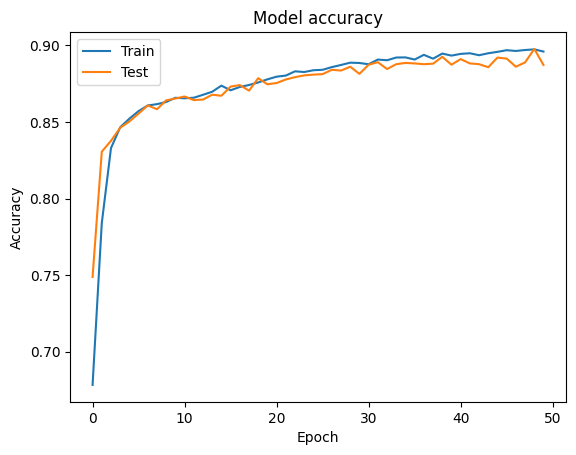

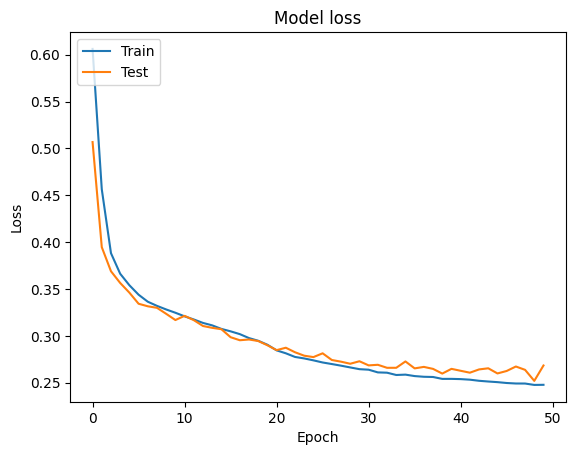

In [ ]:
import matplotlib.pyplot as plt

# Plot training & validation accuracy values
plt.plot(history.history['accuracy'])
plt.plot(history.history['val_accuracy'])
plt.title('Model accuracy')
plt.ylabel('Accuracy')
plt.xlabel('Epoch')
plt.legend(['Train', 'Test'], loc='upper left')
plt.show()

# Plot training & validation loss values
plt.plot(history.history['loss'])
plt.plot(history.history['val_loss'])
plt.title('Model loss')
plt.ylabel('Loss')
plt.xlabel('Epoch')
plt.legend(['Train', 'Test'], loc='upper left')
plt.show()


## **Modeling Skenario 1.b**

In [ ]:
# @title Default title text
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense
from sklearn.preprocessing import StandardScaler

In [ ]:
# @title Default title text
model = Sequential()

# Input layer and first hidden layer with 10 neurons
model.add(Dense(units=10, activation='relu', input_shape=(X_train1.shape[1],)))

# Add second hidden layer with 8 neurons
model.add(Dense(units=8, activation='relu'))

# Add third hidden layer with 6 neurons
model.add(Dense(units=6, activation='relu'))

# Output layer (for binary classification)
model.add(Dense(units=1, activation='sigmoid'))

/usr/local/lib/python3.10/dist-packages/keras/src/layers/core/dense.py:87: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [ ]:
# @title Default title text
model.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])

**Model Training**

In [ ]:
history = model.fit(X_train1, y_train1, epochs=5, batch_size=32, validation_data=(X_test1, y_test1))

Epoch 1/5
46310/46310 ━━━━━━━━━━━━━━━━━━━━ 110s 2ms/step - accuracy: 0.9968 - loss: 0.0133 - val_accuracy: 0.9235 - val_loss: 0.1687
Epoch 2/5
46310/46310 ━━━━━━━━━━━━━━━━━━━━ 106s 2ms/step - accuracy: 0.9968 - loss: 0.0130 - val_accuracy: 0.9202 - val_loss: 0.1724
Epoch 3/5
46310/46310 ━━━━━━━━━━━━━━━━━━━━ 108s 2ms/step - accuracy: 0.9970 - loss: 0.0127 - val_accuracy: 0.9512 - val_loss: 0.0942
Epoch 4/5
46310/46310 ━━━━━━━━━━━━━━━━━━━━ 108s 2ms/step - accuracy: 0.9969 - loss: 0.0130 - val_accuracy: 0.9356 - val_loss: 0.1665
Epoch 5/5
46310/46310 ━━━━━━━━━━━━━━━━━━━━ 139s 2ms/step - accuracy: 0.9970 - loss: 0.0127 - val_accuracy: 0.9225 - val_loss: 0.2014


In [ ]:
test_loss, test_acc = model.evaluate(X_test1, y_test1)
print(f"Test accuracy: {test_acc}")

11578/11578 ━━━━━━━━━━━━━━━━━━━━ 17s 1ms/step - accuracy: 0.9218 - loss: 0.2041
Test accuracy: 0.9225156903266907


In [ ]:
predictions = model.predict(X_test1)
predictions = (predictions > 0.5)  # Convert probabilities to binary (0 or 1)

11578/11578 ━━━━━━━━━━━━━━━━━━━━ 17s 1ms/step


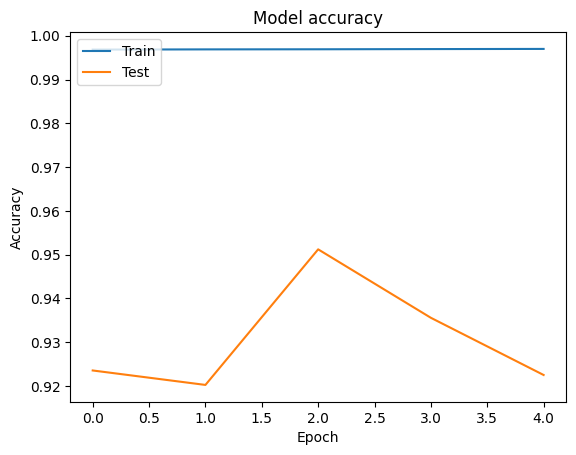

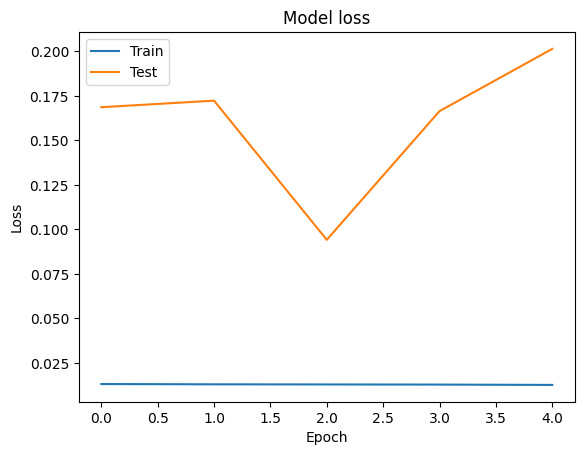

In [ ]:
import matplotlib.pyplot as plt

# Plot training & validation accuracy values
plt.plot(history.history['accuracy'])
plt.plot(history.history['val_accuracy'])
plt.title('Model accuracy')
plt.ylabel('Accuracy')
plt.xlabel('Epoch')
plt.legend(['Train', 'Test'], loc='upper left')
plt.show()

# Plot training & validation loss values
plt.plot(history.history['loss'])
plt.plot(history.history['val_loss'])
plt.title('Model loss')
plt.ylabel('Loss')
plt.xlabel('Epoch')
plt.legend(['Train', 'Test'], loc='upper left')
plt.show()


**Confussion Matrix**

              precision    recall  f1-score   support

           0       1.00      0.93      0.96    368577
           1       0.02      0.33      0.04      1898

    accuracy                           0.92    370475
   macro avg       0.51      0.63      0.50    370475
weighted avg       0.99      0.92      0.95    370475



<Axes: >

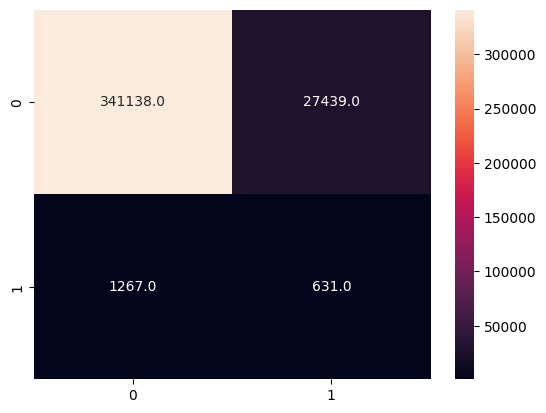

In [ ]:
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report
cm = confusion_matrix(y_test1, predictions)
cr = classification_report(y_test1, predictions)
print(cr)
sns.heatmap(cm, annot=True, fmt='.1f')

## **Modeling Skenario 2**

In [ ]:
# @title Default title text
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense
from sklearn.preprocessing import StandardScaler

In [ ]:
# @title Default title text
model2 = Sequential()

# Input layer and first hidden layer with 10 neurons
model2.add(Dense(units=10, activation='relu', input_shape=(X_train2.shape[1],)))

# Add second hidden layer with 8 neurons
model2.add(Dense(units=6, activation='relu'))

# Add third hidden layer with 6 neurons
model2.add(Dense(units=3, activation='relu'))

# Output layer (for binary classification)
model2.add(Dense(units=1, activation='sigmoid'))

/usr/local/lib/python3.10/dist-packages/keras/src/layers/core/dense.py:87: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [ ]:
# @title Default title text
model2.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])

**Model Training**

In [ ]:
history = model2.fit(X_train2, y_train2, epochs=50, batch_size=32, validation_data=(X_test2, y_test2))

Epoch 1/50
483/483 ━━━━━━━━━━━━━━━━━━━━ 5s 2ms/step - accuracy: 0.5332 - loss: 0.6887 - val_accuracy: 0.5019 - val_loss: 0.8744
Epoch 2/50
483/483 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.7360 - loss: 0.5685 - val_accuracy: 0.5012 - val_loss: 2.5981
Epoch 3/50
483/483 ━━━━━━━━━━━━━━━━━━━━ 3s 3ms/step - accuracy: 0.8082 - loss: 0.4686 - val_accuracy: 0.5095 - val_loss: 3.9414
Epoch 4/50
483/483 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step - accuracy: 0.8352 - loss: 0.4220 - val_accuracy: 0.5178 - val_loss: 4.9395
Epoch 5/50
483/483 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.8497 - loss: 0.3906 - val_accuracy: 0.5074 - val_loss: 6.4430
Epoch 6/50
483/483 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.8484 - loss: 0.3904 - val_accuracy: 0.5134 - val_loss: 6.8594
Epoch 7/50
483/483 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.8589 - loss: 0.3698 - val_accuracy: 0.5131 - val_loss: 7.2968
Epoch 8/50
483/483 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.8572 - loss: 0.3817 - val_accuracy: 0.

In [ ]:
test_loss, test_acc = model2.evaluate(X_test2, y_test2)
print(f"Test accuracy: {test_acc}")

121/121 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.4623 - loss: 2.0505
Test accuracy: 0.4607207775115967


In [ ]:
predictions = model2.predict(X_test2)
predictions = (predictions > 0.5)  # Convert probabilities to binary (0 or 1)

121/121 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step


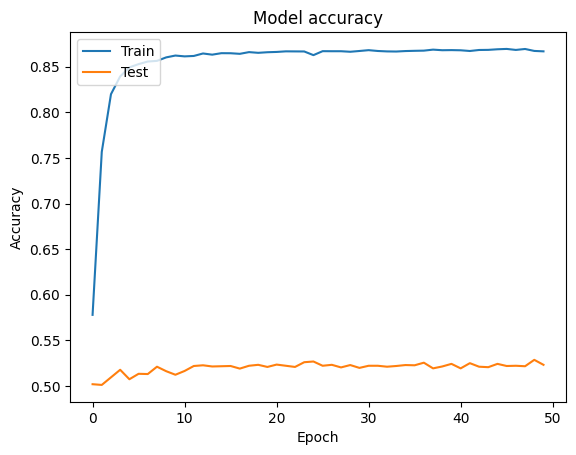

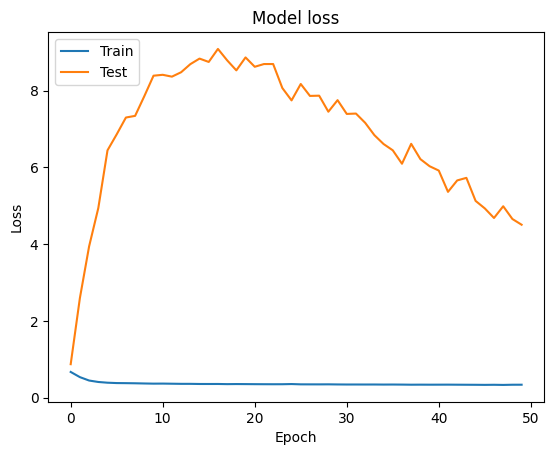

In [ ]:
import matplotlib.pyplot as plt

# Plot training & validation accuracy values
plt.plot(history.history['accuracy'])
plt.plot(history.history['val_accuracy'])
plt.title('Model accuracy')
plt.ylabel('Accuracy')
plt.xlabel('Epoch')
plt.legend(['Train', 'Test'], loc='upper left')
plt.show()

# Plot training & validation loss values
plt.plot(history.history['loss'])
plt.plot(history.history['val_loss'])
plt.title('Model loss')
plt.ylabel('Loss')
plt.xlabel('Epoch')
plt.legend(['Train', 'Test'], loc='upper left')
plt.show()


## **Modeling Skenario 3**

In [ ]:
# @title Default title text
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense
from sklearn.preprocessing import StandardScaler

In [ ]:
# @title Default title text
model3 = Sequential()

# Input layer and first hidden layer with 10 neurons
model3.add(Dense(units=10, activation='relu', input_shape=(X_train3.shape[1],)))

# Add second hidden layer with 8 neurons
model3.add(Dense(units=8, activation='relu'))

# Add third hidden layer with 6 neurons
model3.add(Dense(units=6, activation='relu'))

# Output layer (for binary classification)
model3.add(Dense(units=1, activation='sigmoid'))

In [ ]:
# @title Default title text
model3.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])

**Model Training**

In [ ]:
history3 = model3.fit(X_train3, y_train3, epochs=50, batch_size=32, validation_data=(X_test3, y_test3))

In [ ]:
test_loss, test_acc = model.evaluate(X_test3, y_test3)
print(f"Test accuracy: {test_acc}")

188/188 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.8884 - loss: 0.2717
Test accuracy: 0.8872817754745483


In [ ]:
predictions = model.predict(x_test)
predictions = (predictions > 0.5)  # Convert probabilities to binary (0 or 1)

188/188 ━━━━━━━━━━━━━━━━━━━━ 2s 10ms/step


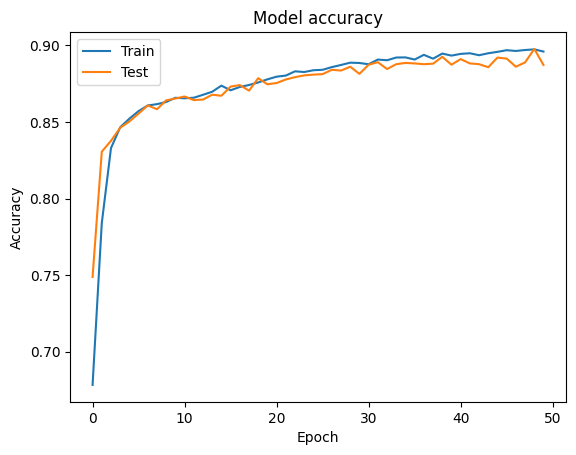

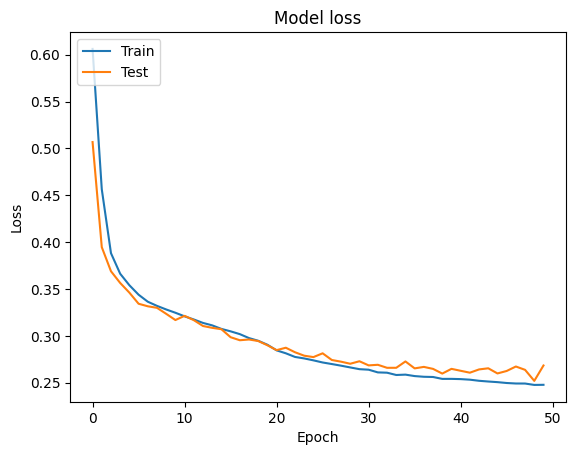

In [ ]:
import matplotlib.pyplot as plt

# Plot training & validation accuracy values
plt.plot(history.history['accuracy'])
plt.plot(history.history['val_accuracy'])
plt.title('Model accuracy')
plt.ylabel('Accuracy')
plt.xlabel('Epoch')
plt.legend(['Train', 'Test'], loc='upper left')
plt.show()

# Plot training & validation loss values
plt.plot(history.history['loss'])
plt.plot(history.history['val_loss'])
plt.title('Model loss')
plt.ylabel('Loss')
plt.xlabel('Epoch')
plt.legend(['Train', 'Test'], loc='upper left')
plt.show()
